# Multimodal Fusion (complex methods: quality-aware, temporal cross-attention, modality transformer)


## Config (paths + choose modes)
Set `AUDIO_MODE` and `TEXT_MODE` to either `'base'` or `'finetuned'`.
- **Base text** = E5-global pipeline (with norm/PCA).
- **Finetuned text** = GTE-base-en-v1.5 finetuned encoder embeddings + head from finetune checkpoint (no PCA).
- **Base audio** = WavLM embeddings + audio-only model checkpoint.
- **Finetuned audio** = finetuned WavLM encoder embeddings + (optionally) audio-only model trained on them.


In [1]:
from pathlib import Path
import os, json, math, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

NUM_TARGETS = 6

DATA_DIR = Path("/home/danila/networks/data")
TRAIN_CSV = DATA_DIR / "train_split.csv"
VALID_CSV = DATA_DIR / "valid_split.csv"

EMOTIONS = ["Admiration","Amusement","Determination","Empathic Pain","Excitement","Joy"]
E = len(EMOTIONS)
ID_WIDTH = 5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

# ===== Choose modes =====
AUDIO_MODE = "finetuned"       # "base" | "finetuned"
TEXT_MODE  = "finetuned"  # "base" | "finetuned"

# ===== Embeddings dirs =====
# Base (existing)
AUDIO_DIR_BASE = DATA_DIR / "embeddings" / "audio_wavlm_large_fps5_finetuned_sec20_v1"
TEXT_DIR_BASE  = DATA_DIR / "embeddings" / "text_e5_large_v2_global_v1"
FACE_DIR       = DATA_DIR / "embeddings" / "faces_emotiefflib_fps5_v1"

# Finetuned (update if your dir name differs)
#AUDIO_DIR_FT = DATA_DIR / "embeddings" / "audio_wavlm_large_fps5_finetuned_sec12_v1"
TEXT_DIR_FT  = DATA_DIR / "embeddings" / "text_gte_base_en_v1_5_finetuned_cls128"

# ===== Unimodal checkpoints =====
# Audio (base) - model that consumes (T,H) embeddings + mask
AUDIO_CKPT_BASE = DATA_DIR / "runs" / "audio_only_variant1_v1" / "best_wavlm.pt"

# Audio (finetuned)
#AUDIO_CKPT_FT = DATA_DIR / "runs" / "audio_wavlm_end2end_fps5_v1" / "best_by_val_pearson.pt"

pkg = torch.load("/home/danila/networks/data/runs/audio_wavlm_end2end_fps5_v1/finetuned_head/head.pt", map_location="cpu")
AUDIO_DIR_FT = Path("/home/danila/networks/data/embeddings") / f"audio_wavlm_large_fps5_finetuned_sec{int(pkg['audio_max_sec'])}_v3"

# Text (base E5) - old pipeline
TEXT_CKPT_BASE = DATA_DIR / "runs" / "text_only_e5_global_v1" / "best_corr.pt"
TEXT_NORM_BASE = DATA_DIR / "runs" / "text_only_e5_global_v1" / "norm_params.npz"

# Text (finetuned GTE)
TEXT_FT_CKPT = DATA_DIR / "runs" / "finetune_mgte_text_only_v1" / "best_by_val_pearson.pt"

# ===== Fusion training =====
RUN_DIR_BASE = DATA_DIR / "runs" / "multimodal_fusion_complex_v1"
RUN_DIR_BASE.mkdir(parents=True, exist_ok=True)
CALIB_PATH  = RUN_DIR_BASE / "calibration_params.npz"

# Fusion methods to run
FUSION_METHODS = ["quality_gated", "modality_transformer", "temporal_xattn"]

# Temporal fusion settings
BUILD_TEMPORAL = True
AUDIO_WIN_STRIDE = None  # None -> win//2
VIDEO_WIN_FRAMES = 32
VIDEO_WIN_STRIDE = 16
MAX_AUDIO_WINDOWS = 20
MAX_VIDEO_WINDOWS = 25


BATCH_SIZE = 128
NUM_WORKERS = 0
PIN_MEMORY = True

LR = 5e-4
WEIGHT_DECAY = 1e-2 #0.0
MAX_EPOCHS = 200
PATIENCE = 30
MIN_DELTA = 1e-4

ACCUM_STEPS = 4
LAMBDA_SMOOTH = 0 #0.02
USE_AMP = True

# If True, initialize fusion logits from *measured* val correlations of unimodal models
# If False, uses the provided priors below.
INIT_FROM_VAL = False #True

# --- per-emotion corr priors (used only if INIT_FROM_VAL=False) ---
corr_audio_prior = {
    "Admiration":0.4660, "Amusement":0.4049, "Determination":0.3638,
    "Empathic Pain":0.5267, "Excitement":0.3811, "Joy":0.3622
}
corr_video_prior = {
    "Admiration":0.0463, "Amusement":0.2354, "Determination":0.1332,
    "Empathic Pain":0.0707, "Excitement":0.2424, "Joy":0.2792
}
corr_text_prior = {
    "Admiration":0.5250, "Amusement":0.4422, "Determination":0.4214,
    "Empathic Pain":0.5253, "Excitement":0.4248, "Joy":0.3742
}

print("DEVICE:", DEVICE)
print("AUDIO_MODE:", AUDIO_MODE, "| TEXT_MODE:", TEXT_MODE)


DEVICE: cuda
AUDIO_MODE: finetuned | TEXT_MODE: finetuned


In [2]:
def load_face_npz(path: Path):
    d = np.load(path, allow_pickle=False)
    emb = d["embeddings"].astype(np.float32)  # (T,D)

    if "face_found" in d.files:
        valid = d["face_found"].astype(bool)
    elif "valid" in d.files:
        valid = d["valid"].astype(bool)
    else:
        valid = np.ones((emb.shape[0],), dtype=bool)

    face_prob = d["face_prob"].astype(np.float32) if "face_prob" in d.files else np.ones((emb.shape[0],), np.float32)
    bbox = d["bbox_xyxy"].astype(np.float32) if "bbox_xyxy" in d.files else np.full((emb.shape[0],4), -1, np.float32)

    ts = d["timestamps_sec"].astype(np.float32) if "timestamps_sec" in d.files else None
    return emb, valid, face_prob, bbox, ts

In [3]:
def init_logits_random_ordered(
    seed: int = 42,
    logit_std: float = 0.15,
    min_gap: float = 0.35,
    gap_jitter: float = 0.35,
    s_std: float = 0.03,
    s_min_gap: float = 0.05,
):
    """
    Random init with guaranteed ordering:
        text > audio > video
    for every emotion at initialization.

    Returns:
        init_logits: [M,E] in MODS order = [audio, text, video]
        init_s:      [M]
    """
    rng = np.random.default_rng(seed)

    # Base per-emotion video logits
    video = rng.normal(loc=-1.2, scale=logit_std, size=(E,))

    # Positive random gaps:
    # audio = video + gap_av
    # text  = audio + gap_ta
    gap_av = min_gap + rng.uniform(0.0, gap_jitter, size=(E,))
    gap_ta = min_gap + rng.uniform(0.0, gap_jitter, size=(E,))

    audio = video + gap_av
    text  = audio + gap_ta

    init_logits = np.stack([audio, text, video], axis=0).astype(np.float32)

    # Global modality offsets, also ordered: text > audio > video
    s_video = rng.normal(loc=0.0, scale=s_std)
    s_audio = s_video + s_min_gap + rng.uniform(0.0, s_min_gap)
    s_text  = s_audio + s_min_gap + rng.uniform(0.0, s_min_gap)

    init_s = np.array([s_audio, s_text, s_video], dtype=np.float32)

    return init_logits, init_s

In [4]:
class TCNBlock(nn.Module):
    def __init__(self, d: int, kernel: int, dilation: int, dropout: float):
        super().__init__()
        padding = (kernel - 1) * dilation // 2
        self.conv1 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)
        self.norm1 = nn.GroupNorm(1, d)
        self.norm2 = nn.GroupNorm(1, d)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        res = x
        x = self.drop(F.gelu(self.norm1(self.conv1(x))))
        x = self.drop(F.gelu(self.norm2(self.conv2(x))))
        return x + res

class TCNEncoder(nn.Module):
    def __init__(self, d: int, layers: int, kernel: int, dropout: float):
        super().__init__()
        self.blocks = nn.ModuleList([TCNBlock(d, kernel, 2**i, dropout) for i in range(layers)])

    def forward(self, x):
        x = x.transpose(1,2)  # [B,d,T]
        for b in self.blocks:
            x = b(x)
        return x.transpose(1,2)  # [B,T,d]

class QualityAttentiveStatsPooling(nn.Module):
    def __init__(self, d: int, attn_hidden: int, dropout: float, temp: float = 1.5):
        super().__init__()
        self.temp = temp
        self.attn = nn.Sequential(
            nn.Linear(d, attn_hidden),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(attn_hidden, 1),
        )
        # learnable weight for quality bias
        self.q_alpha = nn.Parameter(torch.tensor(0.5))

    def forward(self, x, mask, q):
        # x: [B,T,d], mask: [B,T], q: [B,T] in [0,1]
        logits = self.attn(x).squeeze(-1) / self.temp  # [B,T]

        # quality bias: log(q+eps)
        qb = torch.log(q.clamp_min(1e-4))
        logits = logits + self.q_alpha * qb

        logits = logits.masked_fill(~mask, -1e4)
        w = torch.softmax(logits, dim=1)
        w = w * mask.float()
        w = w / (w.sum(dim=1, keepdim=True) + 1e-6)
        w = w.unsqueeze(-1)

        mu = (w * x).sum(dim=1)
        var = (w * (x - mu.unsqueeze(1)).pow(2)).sum(dim=1)
        std = torch.sqrt(var + 1e-6)
        return torch.cat([mu, std], dim=-1)

class VideoFaceModel(nn.Module):
    def __init__(self, din: int, d_model: int, tcn_layers: int, tcn_kernel: int, dropout: float, attn_hidden: int, temp: float):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(din, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
        )
        self.enc = TCNEncoder(d_model, tcn_layers, tcn_kernel, dropout)
        self.pool = QualityAttentiveStatsPooling(d_model, attn_hidden, dropout, temp=temp)
        self.head = nn.Sequential(
            nn.Linear(2*d_model, 2*d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(2*d_model, NUM_TARGETS),
        )

    def forward(self, x, mask, q):
        x = self.proj(x)
        x = self.enc(x)
        z = self.pool(x, mask, q)
        return self.head(z)

In [5]:
# ===== Video checkpoints =====
VIDEO_RUN_DIR = DATA_DIR / "runs" / "video_only_faces_v1"
VIDEO_CKPT = VIDEO_RUN_DIR / "best_by_corr.pt"
VIDEO_STATS = VIDEO_RUN_DIR / "emb_stats.npz"
VIDEO_PCA   = VIDEO_RUN_DIR / "pca_ipca.npz"

assert VIDEO_CKPT.exists(), f"Missing VIDEO_CKPT: {VIDEO_CKPT}"

USE_ZSCORE = True
CLIP_K = 6.0

USE_PCA = False
USE_DELTAS = False
USE_EMA_SMOOTH = False
EMA_BETA = 0.5

MIN_VALID_FRAMES = 5

# load zscore stats
if USE_ZSCORE:
    assert VIDEO_STATS.exists(), f"Missing VIDEO_STATS: {VIDEO_STATS}"
    st = np.load(VIDEO_STATS, allow_pickle=False)
    v_mean = st["emb_mean"].astype(np.float32)
    v_std  = np.clip(st["emb_std"].astype(np.float32), 1e-6, None)
else:
    v_mean, v_std = None, None

# load pca
if USE_PCA:
    assert VIDEO_PCA.exists(), f"Missing VIDEO_PCA: {VIDEO_PCA}"
    p = np.load(VIDEO_PCA, allow_pickle=False)
    pca_components = p["components"].astype(np.float32)  # [D',D]
    pca_mean = p["mean"].astype(np.float32)              # [D]
else:
    pca_components, pca_mean = None, None

# infer input dim from any face file
any_face = next(iter(FACE_DIR.glob("*.npz")), None)
assert any_face is not None, f"No face npz in {FACE_DIR}"
emb0, valid0, face_prob0, bbox0, _ = load_face_npz(any_face)
DIN0 = emb0.shape[1]

# din *= 3
DIN = DIN0
if USE_PCA:
    DIN = int(pca_components.shape[0])
if USE_DELTAS:
    DIN = 3 * DIN

# build video model
D_MODEL = 128
TCN_LAYERS = 4
TCN_KERNEL = 3
DROPOUT = 0.4
ATTN_HIDDEN = 128
ATTN_TEMP = 1.5

video_model = VideoFaceModel(
    din=DIN,
    d_model=D_MODEL,
    tcn_layers=TCN_LAYERS,
    tcn_kernel=TCN_KERNEL,
    dropout=DROPOUT,
    attn_hidden=ATTN_HIDDEN,
    temp=ATTN_TEMP,
).to(DEVICE)

ckpt_v = torch.load(VIDEO_CKPT, map_location="cpu")
state_v = ckpt_v["model_state"] if "model_state" in ckpt_v else ckpt_v
video_model.load_state_dict(state_v, strict=True)
video_model.eval()

print("✅ Loaded video model:", VIDEO_CKPT, "| din:", DIN)

✅ Loaded video model: /home/danila/networks/data/runs/video_only_faces_v1/best_by_corr.pt | din: 1408


In [6]:
def bbox_area_ratio(bbox: np.ndarray):
    x1,y1,x2,y2 = bbox[:,0],bbox[:,1],bbox[:,2],bbox[:,3]
    w = np.clip(x2-x1, 0, None)
    h = np.clip(y2-y1, 0, None)
    return (w*h) / float(FRAME_W*FRAME_H + 1e-6)

def make_quality(face_prob: np.ndarray, bbox: np.ndarray, valid: np.ndarray):
    area = bbox_area_ratio(bbox)
    q = face_prob * np.sqrt(np.clip(area, 0, 1))
    q[~valid] = 0.0
    return np.clip(q, 0.0, 1.0).astype(np.float32)

def preprocess_video_sequence(emb, valid, face_prob, bbox):
    x = emb.astype(np.float32)

    # z-score + clip
    x = (x - v_mean[None,:]) / v_std[None,:]
    x = np.clip(x, -CLIP_K, CLIP_K).astype(np.float32)

    mask = valid.astype(bool)
    q = make_quality(face_prob, bbox, valid)
    return x, mask, q

## 1) Utils: seed + Pearson (mean & per-emotion)

In [7]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

def pearson_per_dim_np(P: np.ndarray, Y: np.ndarray, eps: float = 1e-8):
    # P,Y: [N,E]
    corrs = []
    for k in range(P.shape[1]):
        x = P[:,k].astype(np.float64); y = Y[:,k].astype(np.float64)
        vx = x - x.mean(); vy = y - y.mean()
        denom = (np.sqrt((vx*vx).sum()) * np.sqrt((vy*vy).sum()) + eps)
        corrs.append(float((vx*vy).sum() / denom))
    return float(np.mean(corrs)), corrs

def pearson_corr_torch(preds: torch.Tensor, targets: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    vx = preds - preds.mean(0)
    vy = targets - targets.mean(0)
    corr = (vx * vy).sum(0) / (torch.sqrt((vx**2).sum(0) * (vy**2).sum(0)) + eps)
    return corr.mean()

smooth_loss_fn = nn.SmoothL1Loss(beta=0.2)

def fusion_loss(P: torch.Tensor, Y: torch.Tensor) -> torch.Tensor:
    return (1.0 - pearson_corr_torch(P, Y)) + LAMBDA_SMOOTH * smooth_loss_fn(P, Y)


## 2) Load splits + target normalization (train-only)

In [8]:
train_df = pd.read_csv(TRAIN_CSV, dtype={"Filename": str})
valid_df = pd.read_csv(VALID_CSV, dtype={"Filename": str})

train_df["Filename"] = train_df["Filename"].str.zfill(ID_WIDTH)
valid_df["Filename"] = valid_df["Filename"].str.zfill(ID_WIDTH)

train_ids = train_df["Filename"].tolist()
val_ids   = valid_df["Filename"].tolist()

Ytr_raw = train_df[EMOTIONS].values.astype(np.float32)
Yva_raw = valid_df[EMOTIONS].values.astype(np.float32)

y_mean = Ytr_raw.mean(axis=0)
y_std  = np.clip(Ytr_raw.std(axis=0), 1e-3, None)

Ytr = (Ytr_raw - y_mean[None,:]) / y_std[None,:]
Yva = (Yva_raw - y_mean[None,:]) / y_std[None,:]

np.savez(RUN_DIR_BASE / "target_norm.npz", y_mean=y_mean.astype(np.float32), y_std=y_std.astype(np.float32), emotions=np.array(EMOTIONS))
print("Train:", len(train_df), "Val:", len(valid_df))
print("Saved target norm:", RUN_DIR_BASE / "target_norm.npz")


Train: 8072 Val: 4588
Saved target norm: /home/danila/networks/data/runs/multimodal_fusion_complex_v1/target_norm.npz


## 3) Loading embeddings helpers

In [9]:
def load_audio_npz(path: Path):
    d = np.load(path, allow_pickle=False)
    x = d["embeddings"].astype(np.float32)   # (T,H)
    valid = d["valid"].astype(bool) if "valid" in d.files else np.ones((x.shape[0],), bool)
    return x, valid

def load_text_npz(path: Path):
    d = np.load(path, allow_pickle=False)
    # support both formats: {embedding: [D]} or {embeddings: ...}
    if "embedding" in d.files:
        return d["embedding"].astype(np.float32)
    if "embeddings" in d.files:
        return d["embeddings"].astype(np.float32)
    raise KeyError(f"Unknown keys in {path}: {d.files}")

def load_face_npz(path: Path):
    d = np.load(path, allow_pickle=False)
    emb = d["embeddings"].astype(np.float32)  # (T,D)

    if "face_found" in d.files:
        valid = d["face_found"].astype(bool)
    elif "valid" in d.files:
        valid = d["valid"].astype(bool)
    else:
        valid = np.ones((emb.shape[0],), dtype=bool)

    face_prob = d["face_prob"].astype(np.float32) if "face_prob" in d.files else np.ones((emb.shape[0],), np.float32)
    bbox = d["bbox_xyxy"].astype(np.float32) if "bbox_xyxy" in d.files else np.full((emb.shape[0],4), -1, np.float32)

    ts = d["timestamps_sec"].astype(np.float32) if "timestamps_sec" in d.files else None
    return emb, valid, face_prob, bbox, ts


## 4) Unimodal models
- Audio: consumes (T,H)+mask, outputs 6.
- Text base: consumes transformed E5 embedding.
- Text finetuned: consumes finetuned GTE CLS embedding (no PCA) and applies head weights from finetune checkpoint.
- Video: ridge on clip-level face embedding (quality-weighted mean).


In [10]:
# ------------------------------
# Audio model
# ------------------------------
class TCNBlock(nn.Module):
    def __init__(self, d: int, kernel: int, dilation: int, dropout: float):
        super().__init__()
        padding = (kernel - 1) * dilation // 2
        self.conv1 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)
        self.norm1 = nn.GroupNorm(1, d)
        self.norm2 = nn.GroupNorm(1, d)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        res = x
        x = self.drop(F.gelu(self.norm1(self.conv1(x))))
        x = self.drop(F.gelu(self.norm2(self.conv2(x))))
        return x + res

class TCNEncoder(nn.Module):
    def __init__(self, d: int, layers: int, kernel: int, dropout: float):
        super().__init__()
        self.blocks = nn.ModuleList([TCNBlock(d, kernel, 2**i, dropout) for i in range(layers)])

    def forward(self, x):
        x = x.transpose(1, 2)  # [B,d,T]
        for b in self.blocks:
            x = b(x)
        return x.transpose(1, 2)

class AttentiveStatsPooling(nn.Module):
    def __init__(self, d: int, attn_hidden: int, dropout: float, temp: float = 1.5):
        super().__init__()
        self.temp = temp
        self.attn = nn.Sequential(
            nn.Linear(d, attn_hidden),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(attn_hidden, 1),
        )

    def forward(self, x, mask):
        logits = self.attn(x).squeeze(-1) / self.temp
        logits = logits.masked_fill(~mask, -1e4)
        w = torch.softmax(logits, dim=1)
        w = w * mask.float()
        w = w / (w.sum(dim=1, keepdim=True) + 1e-6)
        w = w.unsqueeze(-1)
        mu = (w * x).sum(dim=1)
        var = (w * (x - mu.unsqueeze(1)).pow(2)).sum(dim=1)
        std = torch.sqrt(var + 1e-6)
        return torch.cat([mu, std], dim=-1)

class AudioWavLMModel(nn.Module):
    def __init__(self, h_in: int, d_model: int = 192, tcn_layers: int = 6, tcn_kernel: int = 3, dropout: float = 0.3, attn_hidden: int = 128):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(h_in, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
        )
        self.enc = TCNEncoder(d_model, tcn_layers, tcn_kernel, dropout)
        self.pool = AttentiveStatsPooling(d_model, attn_hidden, dropout, temp=1.5)
        self.head = nn.Sequential(
            nn.Linear(2*d_model, 2*d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(2*d_model, E),
        )

    def forward(self, x, mask):
        x = self.proj(x)
        x = self.enc(x)
        z = self.pool(x, mask)
        return self.head(z)

# ------------------------------
# Text base model (E5 embeddings with norm/PCA)
# ------------------------------
class TextMLP(nn.Module):
    def __init__(self, din: int, hidden: int = 512, dropout: float = 0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(din),
            nn.Linear(din, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, E),
        )
    def forward(self, x):
        return self.net(x)

# ------------------------------
# Text finetuned head (GTE CLS embedding -> 6)
# ------------------------------
class GTEHead(nn.Module):
    def __init__(self, d_in: int, hidden: int = 512, dropout: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_in, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, E),
        )
    def forward(self, x):
        return self.net(x)


In [11]:
pkg = torch.load("/home/danila/networks/data/runs/audio_wavlm_end2end_fps5_v1/finetuned_head/head.pt", map_location="cpu")
audio_model = AudioWavLMModel(h_in=pkg["h_in"]).to(DEVICE)
audio_model.load_state_dict(pkg["head_state"], strict=True)
audio_model.eval()

AudioWavLMModel(
  (proj): Sequential(
    (0): Linear(in_features=1024, out_features=192, bias=True)
    (1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (2): Dropout(p=0.3, inplace=False)
  )
  (enc): TCNEncoder(
    (blocks): ModuleList(
      (0): TCNBlock(
        (conv1): Conv1d(192, 192, kernel_size=(3,), stride=(1,), padding=(1,))
        (conv2): Conv1d(192, 192, kernel_size=(3,), stride=(1,), padding=(1,))
        (norm1): GroupNorm(1, 192, eps=1e-05, affine=True)
        (norm2): GroupNorm(1, 192, eps=1e-05, affine=True)
        (drop): Dropout(p=0.3, inplace=False)
      )
      (1): TCNBlock(
        (conv1): Conv1d(192, 192, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
        (conv2): Conv1d(192, 192, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
        (norm1): GroupNorm(1, 192, eps=1e-05, affine=True)
        (norm2): GroupNorm(1, 192, eps=1e-05, affine=True)
        (drop): Dropout(p=0.3, inplace=False)
      )
      (2): TC

## 5) Build predictors for chosen modes

In [12]:
def pick_audio_dir():
    return AUDIO_DIR_FT if AUDIO_MODE == "finetuned" else AUDIO_DIR_BASE

def pick_text_dir():
    return TEXT_DIR_FT if TEXT_MODE == "finetuned" else TEXT_DIR_BASE

#def pick_audio_ckpt():
#    return AUDIO_CKPT_FT if AUDIO_MODE == "finetuned" else AUDIO_CKPT_BASE

def report_dir(name, p: Path):
    print(f"{name}: {p} | exists={p.exists()}")

report_dir("AUDIO_DIR", pick_audio_dir())
report_dir("TEXT_DIR",  pick_text_dir())
report_dir("FACE_DIR",  FACE_DIR)
#report_dir("AUDIO_CKPT", pick_audio_ckpt())
if TEXT_MODE == "base":
    report_dir("TEXT_CKPT_BASE", TEXT_CKPT_BASE)
    report_dir("TEXT_NORM_BASE", TEXT_NORM_BASE)
else:
    report_dir("TEXT_FT_CKPT", TEXT_FT_CKPT)


AUDIO_DIR: /home/danila/networks/data/embeddings/audio_wavlm_large_fps5_finetuned_sec20_v3 | exists=True
TEXT_DIR: /home/danila/networks/data/embeddings/text_gte_base_en_v1_5_finetuned_cls128 | exists=True
FACE_DIR: /home/danila/networks/data/embeddings/faces_emotiefflib_fps5_v1 | exists=True
TEXT_FT_CKPT: /home/danila/networks/data/runs/finetune_mgte_text_only_v1/best_by_val_pearson.pt | exists=True


## 6) Load unimodal models (audio/text)

In [13]:
# ---- AUDIO model ----
any_audio = next(iter(pick_audio_dir().glob("*.npz")), None)
assert any_audio is not None, f"No audio npz found in {pick_audio_dir()}"
x0, m0 = load_audio_npz(any_audio)
H_AUDIO = x0.shape[1]

#audio_model = AudioWavLMModel(H_AUDIO).to(DEVICE)
#ckpt_a = torch.load(pick_audio_ckpt(), map_location=DEVICE)
# accept either {'model_state':...} or direct state_dict
#state_a = ckpt_a.get("model_state", ckpt_a)
#audio_model.load_state_dict(state_a, strict=True)
#audio_model.eval()
#print("Loaded audio model:", pick_audio_ckpt(), "| H_AUDIO:", H_AUDIO)

# ---- TEXT model ----
if TEXT_MODE == "base":
    norm = np.load(TEXT_NORM_BASE, allow_pickle=False)
    x_mean = norm["x_mean"].astype(np.float32)
    x_scale = norm["x_scale"].astype(np.float32)

    USE_PCA_TEXT = bool(int(norm["use_pca"][0]))
    pca_dim_text = int(norm["pca_dim"][0])
    pca_components = norm["pca_components"].astype(np.float32)
    pca_mean = norm["pca_mean"].astype(np.float32)

    raw_dim = x_mean.shape[0]
    din_text = pca_dim_text if USE_PCA_TEXT else raw_dim

    text_model = TextMLP(din_text).to(DEVICE)
    ckpt_t = torch.load(TEXT_CKPT_BASE, map_location=DEVICE)
    state_t = ckpt_t.get("model_state", ckpt_t)
    text_model.load_state_dict(state_t, strict=True)
    text_model.eval()

    print("Loaded base text model:", TEXT_CKPT_BASE, "| use_pca:", USE_PCA_TEXT, "| din:", din_text)

    def text_transform_base(x_raw: np.ndarray) -> np.ndarray:
        x = (x_raw - x_mean) / x_scale
        if USE_PCA_TEXT:
            x = (x - pca_mean) @ pca_components.T
        return x.astype(np.float32)

else:
    any_text = next(iter(TEXT_DIR_FT.glob("*.npz")), None)
    assert any_text is not None, f"No text npz found in {TEXT_DIR_FT}"
    x0 = load_text_npz(any_text)
    D_TEXT = int(x0.shape[0])
    
    # head architecture MUST match training:
    text_head = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(D_TEXT, 512),
        nn.GELU(),
        nn.Dropout(0.2),
        nn.Linear(512, E),
    ).to(DEVICE).eval()
    
    ckpt_t = torch.load(TEXT_FT_CKPT, map_location="cpu")
    state = ckpt_t["model_state"] if "model_state" in ckpt_t else ckpt_t
    
    # Take ONLY head.* weights and load them into Sequential (keys become '0.weight', '1.weight', ...)
    head_sd = {k.replace("head.", ""): v for k, v in state.items() if k.startswith("head.")}
    assert len(head_sd) > 0, "No head.* keys found in checkpoint — check TEXT_FT_CKPT path!"
    
    # IMPORTANT: strict=True so we fail loudly if mismatch
    missing, unexpected = text_head.load_state_dict(head_sd, strict=True)
    print("✅ Loaded finetuned text head from:", TEXT_FT_CKPT, "| D_TEXT:", D_TEXT)
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)


✅ Loaded finetuned text head from: /home/danila/networks/data/runs/finetune_mgte_text_only_v1/best_by_val_pearson.pt | D_TEXT: 768
Missing keys: []
Unexpected keys: []


## 7) Predict unimodal outputs on train/val

In [14]:
@torch.inference_mode()
def predict_audio_with_head(ids: list[str], audio_dir: Path, head_pt: Path):
    pkg = torch.load(head_pt, map_location="cpu")
    head_sd = pkg["head_state"]
    num_bins = int(pkg["num_bins"])
    h_in = int(pkg["h_in"])

    # head model
    audio_model = AudioWavLMModel(h_in=h_in).to(DEVICE)
    audio_model.load_state_dict(head_sd, strict=True)
    audio_model.eval()

    P = np.full((len(ids), E), np.nan, np.float32)
    avail = np.zeros((len(ids),), dtype=bool)

    for i, vid in enumerate(tqdm(ids, desc=f"Audio preds (head+emb)")):
        p = audio_dir / f"{vid}.npz"
        if not p.exists():
            continue
        x, valid = load_audio_npz(p)  # x: [T,H]

        # enforce expected length
        T, H = x.shape
        if H != h_in:
            continue

        if T < num_bins:
            pad = num_bins - T
            x = np.pad(x, ((0,pad),(0,0)), mode="constant", constant_values=0.0)
            valid = np.pad(valid, (0,pad), mode="constant", constant_values=False)
        elif T > num_bins:
            x = x[:num_bins]
            valid = valid[:num_bins]

        if valid.sum() < 5:
            continue

        xt = torch.from_numpy(x).unsqueeze(0).to(DEVICE)
        mt = torch.from_numpy(valid).unsqueeze(0).to(DEVICE)

        out = audio_model(xt, mt).detach().float().cpu().numpy()[0]
        P[i] = out
        avail[i] = True

    return P, avail


@torch.inference_mode()
def predict_text(ids: list[str], text_dir: Path):
    P = np.full((len(ids), E), np.nan, np.float32)
    avail = np.zeros((len(ids),), dtype=bool)

    for i, vid in enumerate(tqdm(ids, desc=f"Text preds ({text_dir.name})")):
        p = text_dir / f"{vid}.npz"
        if not p.exists():
            continue

        x_raw = load_text_npz(p)

        if TEXT_MODE == "base":
            x = text_transform_base(x_raw)
            xt = torch.from_numpy(x).unsqueeze(0).to(DEVICE)
            out = text_model(xt).detach().float().cpu().numpy()[0]
        else:
            xt = torch.from_numpy(x_raw.astype(np.float32)).unsqueeze(0).to(DEVICE)
            out = text_head(xt).detach().float().cpu().numpy()[0]

        P[i] = out
        avail[i] = True

    return P, avail


# video predictor (unchanged): ridge over clip-embedding
FRAME_W, FRAME_H = 1280, 720

def quality_weights(face_prob: np.ndarray, bbox: np.ndarray, valid: np.ndarray):
    x1,y1,x2,y2 = bbox[:,0],bbox[:,1],bbox[:,2],bbox[:,3]
    w = np.clip(x2-x1, 0, None)
    h = np.clip(y2-y1, 0, None)
    area_ratio = (w*h) / float(FRAME_W*FRAME_H + 1e-6)
    q = face_prob * np.sqrt(np.clip(area_ratio, 0, 1))
    q[~valid] = 0.0
    return q.astype(np.float32)

def face_clip_embed_mu_std(emb: np.ndarray, valid: np.ndarray, q: np.ndarray):
    # q already includes validity/quality
    w = q.copy()
    if w.sum() <= 1e-6:
        vv = valid.astype(np.float32)
        if vv.sum() <= 1e-6:
            return None
        w = vv
    w = w / (w.sum() + 1e-6)

    mu = (emb * w[:, None]).sum(0)
    var = (w[:, None] * (emb - mu[None, :])**2).sum(0)
    std = np.sqrt(var + 1e-6)
    return np.concatenate([mu, std], axis=0).astype(np.float32)

#def collect_video_clip_embs(ids: list[str]):
#    X = []
#    avail = []
#    for vid in tqdm(ids, desc="Video clip emb"):
#        p = FACE_DIR / f"{vid}.npz"
#        if not p.exists():
#            X.append(None); avail.append(False); continue
#        emb, valid, face_prob, bbox = load_face_npz(p)
#        q = quality_weights(face_prob, bbox, valid)
#        ce = face_clip_embed_mu_std(emb, valid, q)
#        if ce is None:
#            X.append(None); avail.append(False); continue
#        X.append(ce.astype(np.float32)); avail.append(True)
#    return X, np.array(avail, dtype=bool)

#def predict_video_from_clip_embs(X_list, avail_mask):
#    P = np.full((len(X_list), E), np.nan, np.float32)
#    idxs = np.where(avail_mask)[0]
#    if len(idxs) == 0:
#        return P
#    X = np.stack([X_list[i] for i in idxs], axis=0)
#    Xs = v_scaler.transform(X)
#    pred = ridge_v.predict(Xs).astype(np.float32)
#    P[idxs] = pred
#    return P

@torch.inference_mode()
def predict_video(ids: list[str]):
    P = np.full((len(ids), E), np.nan, np.float32)
    avail = np.zeros((len(ids),), dtype=bool)

    for i, vid in enumerate(tqdm(ids, desc="Video preds (VideoFaceModel)")):
        p = FACE_DIR / f"{vid}.npz"
        if not p.exists():
            continue

        emb, valid, face_prob, bbox, _ = load_face_npz(p)
        if valid.sum() < MIN_VALID_FRAMES:
            continue

        x, m, q = preprocess_video_sequence(emb, valid, face_prob, bbox)

        xt = torch.from_numpy(x).unsqueeze(0).to(DEVICE)   # [1,T,D]
        mt = torch.from_numpy(m).unsqueeze(0).to(DEVICE)   # [1,T]
        qt = torch.from_numpy(q).unsqueeze(0).to(DEVICE)   # [1,T]

        out = video_model(xt, mt, qt).detach().float().cpu().numpy()[0]
        P[i] = out
        avail[i] = True

    return P, avail

# ---- Run predictions ----
audio_dir = pick_audio_dir()
text_dir  = pick_text_dir()

In [15]:
#P_a_tr, A_a_tr = predict_audio(train_ids, audio_dir)
#P_a_va, A_a_va = predict_audio(val_ids, audio_dir)
AUDIO_HEAD_PT = DATA_DIR / "runs" / "audio_wavlm_end2end_fps5_v1" / "finetuned_head" / "head.pt"

P_a_tr, A_a_tr = predict_audio_with_head(train_ids, audio_dir, AUDIO_HEAD_PT)
P_a_va, A_a_va = predict_audio_with_head(val_ids, audio_dir, AUDIO_HEAD_PT)
print("Audio availability train/val:", A_a_tr.mean(), A_a_va.mean())

Audio preds (head+emb):   0%|          | 0/8072 [00:00<?, ?it/s]

Audio preds (head+emb):   0%|          | 0/4588 [00:00<?, ?it/s]

Audio availability train/val: 0.9754707631318137 0.9655623365300785


In [16]:
P_t_tr, A_t_tr = predict_text(train_ids, text_dir)
P_t_va, A_t_va = predict_text(val_ids, text_dir)
print("Text availability train/val:", A_t_tr.mean(), A_t_va.mean())

Text preds (text_gte_base_en_v1_5_finetuned_cls128):   0%|          | 0/8072 [00:00<?, ?it/s]

Text preds (text_gte_base_en_v1_5_finetuned_cls128):   0%|          | 0/4588 [00:00<?, ?it/s]

Text availability train/val: 1.0 1.0


In [17]:
#Xv_tr_list, A_v_tr = collect_video_clip_embs(train_ids)
#Xv_va_list, A_v_va = collect_video_clip_embs(val_ids)
#print("Video availability train/val:", A_v_tr.mean(), A_v_va.mean())

In [18]:
P_v_tr, A_v_tr = predict_video(train_ids)
P_v_va, A_v_va = predict_video(val_ids)

Video preds (VideoFaceModel):   0%|          | 0/8072 [00:00<?, ?it/s]

Video preds (VideoFaceModel):   0%|          | 0/4588 [00:00<?, ?it/s]

## 8) Calibration per modality (affine per emotion)

In [19]:
def fit_calibration(P: np.ndarray, Y: np.ndarray, avail: np.ndarray):
    a = np.ones((E,), np.float32)
    b = np.zeros((E,), np.float32)

    idx = np.where(avail)[0]
    if len(idx) < 10:
        return a, b

    X = P[idx].astype(np.float64)
    T = Y[idx].astype(np.float64)

    for k in range(E):
        x = X[:,k]; y = T[:,k]
        A = np.stack([x, np.ones_like(x)], axis=1)
        sol, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
        ak, bk = sol[0], sol[1]
        if ak < 0: ak = 0.0
        a[k] = float(ak)
        b[k] = float(bk)
    return a, b

def apply_calib(P: np.ndarray, a: np.ndarray, b: np.ndarray):
    out = P.copy()
    nanmask = np.isnan(out)
    out = out * a[None,:] + b[None,:]
    out[nanmask] = np.nan
    return out

a_a, b_a = fit_calibration(P_a_tr, Ytr, A_a_tr)
a_t, b_t = fit_calibration(P_t_tr, Ytr, A_t_tr)
a_v, b_v = fit_calibration(P_v_tr, Ytr, A_v_tr)

P_a_tr_c = apply_calib(P_a_tr, a_a, b_a)
P_a_va_c = apply_calib(P_a_va, a_a, b_a)

P_t_tr_c = apply_calib(P_t_tr, a_t, b_t)
P_t_va_c = apply_calib(P_t_va, a_t, b_t)

P_v_tr_c = apply_calib(P_v_tr, a_v, b_v)
P_v_va_c = apply_calib(P_v_va, a_v, b_v)

np.savez(CALIB_PATH, a_audio=a_a, b_audio=b_a, a_text=a_t, b_text=b_t, a_video=a_v, b_video=b_v, emotions=np.array(EMOTIONS))
print("Saved calibration:", CALIB_PATH)


Saved calibration: /home/danila/networks/data/runs/multimodal_fusion_complex_v1/calibration_params.npz


## 9) Report unimodal performance (VAL, per emotion)

In [20]:
def report_unimodal(name: str, P: np.ndarray, Y: np.ndarray, avail: np.ndarray):
    idx = np.where(avail)[0]
    if len(idx) < 10:
        print(name, "too few samples")
        return
    mean_corr, per = pearson_per_dim_np(P[idx], Y[idx])
    print(f"{name}: mean={mean_corr:.4f}")
    for emo, c in zip(EMOTIONS, per):
        print(f"  - {emo:14s}: {c:.4f}")

report_unimodal("AUDIO", P_a_va_c, Yva, A_a_va)
report_unimodal("TEXT",  P_t_va_c, Yva, A_t_va)
report_unimodal("VIDEO", P_v_va_c, Yva, A_v_va)


AUDIO: mean=0.4238
  - Admiration    : 0.4763
  - Amusement     : 0.4130
  - Determination : 0.3663
  - Empathic Pain : 0.5372
  - Excitement    : 0.3841
  - Joy           : 0.3659
TEXT: mean=0.5373
  - Admiration    : 0.6030
  - Amusement     : 0.5608
  - Determination : 0.4880
  - Empathic Pain : 0.5846
  - Excitement    : 0.5041
  - Joy           : 0.4831
VIDEO: mean=0.1690
  - Admiration    : 0.0453
  - Amusement     : 0.2255
  - Determination : 0.1308
  - Empathic Pain : 0.0853
  - Excitement    : 0.2497
  - Joy           : 0.2772


## 10) Build fusion tensors + sanitize

In [21]:
def stack_mod_preds(Pa, Pt, Pv):
    return np.stack([Pa, Pt, Pv], axis=1).astype(np.float32)  # [N,3,6]

X_tr_f = stack_mod_preds(P_a_tr_c, P_t_tr_c, P_v_tr_c)
X_va_f = stack_mod_preds(P_a_va_c, P_t_va_c, P_v_va_c)

A_tr_f = np.stack([A_a_tr, A_t_tr, A_v_tr], axis=1)
A_va_f = np.stack([A_a_va, A_t_va, A_v_va], axis=1)

Y_tr_f = Ytr.astype(np.float32)
Y_va_f = Yva.astype(np.float32)

def sanitize_fusion_inputs(X, A, Y):
    X2 = X.copy()
    X2[np.isnan(X2)] = 0.0
    keep = A.any(axis=1)
    return X2[keep], A[keep], Y[keep], keep

X_tr_f, A_tr_f, Y_tr_f, keep_tr = sanitize_fusion_inputs(X_tr_f, A_tr_f, Y_tr_f)
X_va_f, A_va_f, Y_va_f, keep_va = sanitize_fusion_inputs(X_va_f, A_va_f, Y_va_f)

print("Fusion shapes:", X_tr_f.shape, A_tr_f.shape, Y_tr_f.shape)
print("Avail mean per modality (train/val):", A_tr_f.mean(axis=0), A_va_f.mean(axis=0))


Fusion shapes: (8072, 3, 6) (8072, 3) (8072, 6)
Avail mean per modality (train/val): [0.97547076 1.         0.96977205] [0.96556234 1.         0.95793374]


## 11) Quality + temporal features for fusion


In [22]:
# ---- Quality features per modality ----
def compute_audio_quality(ids: list[str], audio_dir: Path, head_pt: Path):
    pkg = torch.load(head_pt, map_location="cpu")
    num_bins = int(pkg["num_bins"])
    h_in = int(pkg["h_in"])

    q = np.zeros((len(ids),), np.float32)
    avail = np.zeros((len(ids),), bool)
    for i, vid in enumerate(tqdm(ids, desc="Audio quality")):
        p = audio_dir / f"{vid}.npz"
        if not p.exists():
            continue
        x, valid = load_audio_npz(p)
        if x.shape[1] != h_in:
            continue
        # align to expected length
        T = x.shape[0]
        if T < num_bins:
            pad = num_bins - T
            valid = np.pad(valid, (0, pad), mode="constant", constant_values=False)
        elif T > num_bins:
            valid = valid[:num_bins]
        if valid.sum() < 5:
            continue
        q[i] = float(valid.mean())
        avail[i] = True
    return q, avail

def compute_text_quality(ids: list[str], text_dir: Path):
    q = np.zeros((len(ids),), np.float32)
    avail = np.zeros((len(ids),), bool)
    for i, vid in enumerate(tqdm(ids, desc="Text quality")):
        p = text_dir / f"{vid}.npz"
        if not p.exists():
            continue
        try:
            x = load_text_npz(p)
        except Exception:
            continue
        # simple proxy: normalized embedding norm in [0,1]
        norm = float(np.linalg.norm(x))
        q[i] = float(np.tanh(norm / 10.0))
        avail[i] = True
    return q, avail

def compute_video_quality(ids: list[str]):
    q = np.zeros((len(ids),), np.float32)
    avail = np.zeros((len(ids),), bool)
    for i, vid in enumerate(tqdm(ids, desc="Video quality")):
        p = FACE_DIR / f"{vid}.npz"
        if not p.exists():
            continue
        emb, valid, face_prob, bbox, _ = load_face_npz(p)
        if valid.sum() < MIN_VALID_FRAMES:
            continue
        q_seq = make_quality(face_prob, bbox, valid)
        q[i] = float(q_seq[valid].mean()) if valid.any() else 0.0
        avail[i] = True
    return q, avail

AUDIO_HEAD_PT = DATA_DIR / "runs" / "audio_wavlm_end2end_fps5_v1" / "finetuned_head" / "head.pt"

Q_a_tr, Aqa_tr = compute_audio_quality(train_ids, audio_dir, AUDIO_HEAD_PT)
Q_a_va, Aqa_va = compute_audio_quality(val_ids, audio_dir, AUDIO_HEAD_PT)

Q_t_tr, Aqt_tr = compute_text_quality(train_ids, text_dir)
Q_t_va, Aqt_va = compute_text_quality(val_ids, text_dir)

Q_v_tr, Aqv_tr = compute_video_quality(train_ids)
Q_v_va, Aqv_va = compute_video_quality(val_ids)

Q_tr_f = np.stack([Q_a_tr, Q_t_tr, Q_v_tr], axis=1)
Q_va_f = np.stack([Q_a_va, Q_t_va, Q_v_va], axis=1)

Q_tr_f = Q_tr_f[keep_tr]
Q_va_f = Q_va_f[keep_va]

# filtered text preds/avail for temporal fusion
P_t_tr_c_f = P_t_tr_c[keep_tr]
P_t_va_c_f = P_t_va_c[keep_va]
A_t_tr_f = A_t_tr[keep_tr]
A_t_va_f = A_t_va[keep_va]

print("Quality shapes:", Q_tr_f.shape, Q_va_f.shape)

# ---- Temporal windowed predictions for temporal fusion ----
def build_audio_window_preds(ids: list[str], audio_dir: Path, head_pt: Path, stride_bins=None, max_windows=20):
    pkg = torch.load(head_pt, map_location="cpu")
    head_sd = pkg["head_state"]
    num_bins = int(pkg["num_bins"])
    h_in = int(pkg["h_in"])

    audio_model = AudioWavLMModel(h_in=h_in).to(DEVICE)
    audio_model.load_state_dict(head_sd, strict=True)
    audio_model.eval()

    if stride_bins is None:
        stride_bins = max(1, num_bins // 2)

    P_seq = []
    M_seq = []
    Q_seq = []

    for vid in tqdm(ids, desc="Audio windows"):
        p = audio_dir / f"{vid}.npz"
        if not p.exists():
            P_seq.append(np.zeros((1, E), np.float32))
            M_seq.append(np.zeros((1,), bool))
            Q_seq.append(np.zeros((1,), np.float32))
            continue
        x, valid = load_audio_npz(p)
        if x.shape[1] != h_in:
            P_seq.append(np.zeros((1, E), np.float32))
            M_seq.append(np.zeros((1,), bool))
            Q_seq.append(np.zeros((1,), np.float32))
            continue

        T = x.shape[0]
        windows = []
        masks = []
        quals = []

        for start in range(0, max(1, T - num_bins + 1), stride_bins):
            end = start + num_bins
            if end > T:
                break
            xw = x[start:end]
            vw = valid[start:end]
            if vw.sum() < 5:
                continue
            xt = torch.from_numpy(xw).unsqueeze(0).to(DEVICE)
            mt = torch.from_numpy(vw).unsqueeze(0).to(DEVICE)
            out = audio_model(xt, mt).detach().float().cpu().numpy()[0]
            windows.append(out)
            masks.append(True)
            quals.append(float(vw.mean()))
            if len(windows) >= max_windows:
                break

        if len(windows) == 0:
            windows = [np.zeros((E,), np.float32)]
            masks = [False]
            quals = [0.0]

        P_seq.append(np.stack(windows, axis=0))
        M_seq.append(np.array(masks, bool))
        Q_seq.append(np.array(quals, np.float32))

    # pad to max length
    maxT = max(x.shape[0] for x in P_seq)
    P_pad = np.zeros((len(P_seq), maxT, E), np.float32)
    M_pad = np.zeros((len(P_seq), maxT), bool)
    Q_pad = np.zeros((len(P_seq), maxT), np.float32)
    for i, (p, m, q) in enumerate(zip(P_seq, M_seq, Q_seq)):
        t = p.shape[0]
        P_pad[i, :t] = p
        M_pad[i, :t] = m
        Q_pad[i, :t] = q
    return P_pad, M_pad, Q_pad

@torch.inference_mode()
def build_video_window_preds(ids: list[str], win_frames=32, stride=16, max_windows=25):
    P_seq = []
    M_seq = []
    Q_seq = []

    for vid in tqdm(ids, desc="Video windows"):
        p = FACE_DIR / f"{vid}.npz"
        if not p.exists():
            P_seq.append(np.zeros((1, E), np.float32))
            M_seq.append(np.zeros((1,), bool))
            Q_seq.append(np.zeros((1,), np.float32))
            continue

        emb, valid, face_prob, bbox, _ = load_face_npz(p)
        if valid.sum() < MIN_VALID_FRAMES:
            P_seq.append(np.zeros((1, E), np.float32))
            M_seq.append(np.zeros((1,), bool))
            Q_seq.append(np.zeros((1,), np.float32))
            continue

        x, mask, q = preprocess_video_sequence(emb, valid, face_prob, bbox)
        T = x.shape[0]
        windows = []
        masks = []
        quals = []

        for start in range(0, max(1, T - win_frames + 1), stride):
            end = start + win_frames
            if end > T:
                break
            xw = x[start:end]
            mw = mask[start:end]
            qw = q[start:end]
            if mw.sum() < MIN_VALID_FRAMES:
                continue
            xt = torch.from_numpy(xw).unsqueeze(0).to(DEVICE)
            mt = torch.from_numpy(mw).unsqueeze(0).to(DEVICE)
            qt = torch.from_numpy(qw).unsqueeze(0).to(DEVICE)
            out = video_model(xt, mt, qt).detach().float().cpu().numpy()[0]
            windows.append(out)
            masks.append(True)
            quals.append(float(qw[mw].mean()) if mw.any() else 0.0)
            if len(windows) >= max_windows:
                break

        if len(windows) == 0:
            windows = [np.zeros((E,), np.float32)]
            masks = [False]
            quals = [0.0]

        P_seq.append(np.stack(windows, axis=0))
        M_seq.append(np.array(masks, bool))
        Q_seq.append(np.array(quals, np.float32))

    maxT = max(x.shape[0] for x in P_seq)
    P_pad = np.zeros((len(P_seq), maxT, E), np.float32)
    M_pad = np.zeros((len(P_seq), maxT), bool)
    Q_pad = np.zeros((len(P_seq), maxT), np.float32)
    for i, (p, m, q) in enumerate(zip(P_seq, M_seq, Q_seq)):
        t = p.shape[0]
        P_pad[i, :t] = p
        M_pad[i, :t] = m
        Q_pad[i, :t] = q
    return P_pad, M_pad, Q_pad

if BUILD_TEMPORAL:
    cache_dir = RUN_DIR_BASE / "temporal_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)

    cache_audio_tr = cache_dir / "audio_windows_train.npz"
    cache_audio_va = cache_dir / "audio_windows_val.npz"
    cache_video_tr = cache_dir / "video_windows_train.npz"
    cache_video_va = cache_dir / "video_windows_val.npz"

    if cache_audio_tr.exists() and cache_audio_va.exists():
        d = np.load(cache_audio_tr)
        P_a_seq_tr, M_a_seq_tr, Q_a_seq_tr = d["P"], d["M"], d["Q"]
        d = np.load(cache_audio_va)
        P_a_seq_va, M_a_seq_va, Q_a_seq_va = d["P"], d["M"], d["Q"]
    else:
        P_a_seq_tr, M_a_seq_tr, Q_a_seq_tr = build_audio_window_preds(
            train_ids, audio_dir, AUDIO_HEAD_PT, stride_bins=AUDIO_WIN_STRIDE, max_windows=MAX_AUDIO_WINDOWS
        )
        P_a_seq_va, M_a_seq_va, Q_a_seq_va = build_audio_window_preds(
            val_ids, audio_dir, AUDIO_HEAD_PT, stride_bins=AUDIO_WIN_STRIDE, max_windows=MAX_AUDIO_WINDOWS
        )
        np.savez(cache_audio_tr, P=P_a_seq_tr, M=M_a_seq_tr, Q=Q_a_seq_tr)
        np.savez(cache_audio_va, P=P_a_seq_va, M=M_a_seq_va, Q=Q_a_seq_va)

    if cache_video_tr.exists() and cache_video_va.exists():
        d = np.load(cache_video_tr)
        P_v_seq_tr, M_v_seq_tr, Q_v_seq_tr = d["P"], d["M"], d["Q"]
        d = np.load(cache_video_va)
        P_v_seq_va, M_v_seq_va, Q_v_seq_va = d["P"], d["M"], d["Q"]
    else:
        P_v_seq_tr, M_v_seq_tr, Q_v_seq_tr = build_video_window_preds(
            train_ids, win_frames=VIDEO_WIN_FRAMES, stride=VIDEO_WIN_STRIDE, max_windows=MAX_VIDEO_WINDOWS
        )
        P_v_seq_va, M_v_seq_va, Q_v_seq_va = build_video_window_preds(
            val_ids, win_frames=VIDEO_WIN_FRAMES, stride=VIDEO_WIN_STRIDE, max_windows=MAX_VIDEO_WINDOWS
        )
        np.savez(cache_video_tr, P=P_v_seq_tr, M=M_v_seq_tr, Q=Q_v_seq_tr)
        np.savez(cache_video_va, P=P_v_seq_va, M=M_v_seq_va, Q=Q_v_seq_va)

        # align temporal sequences with sanitized keep masks
        P_a_seq_tr, M_a_seq_tr, Q_a_seq_tr = P_a_seq_tr[keep_tr], M_a_seq_tr[keep_tr], Q_a_seq_tr[keep_tr]
        P_a_seq_va, M_a_seq_va, Q_a_seq_va = P_a_seq_va[keep_va], M_a_seq_va[keep_va], Q_a_seq_va[keep_va]
        P_v_seq_tr, M_v_seq_tr, Q_v_seq_tr = P_v_seq_tr[keep_tr], M_v_seq_tr[keep_tr], Q_v_seq_tr[keep_tr]
        P_v_seq_va, M_v_seq_va, Q_v_seq_va = P_v_seq_va[keep_va], M_v_seq_va[keep_va], Q_v_seq_va[keep_va]
        print("Temporal audio seq shape:", P_a_seq_tr.shape, P_a_seq_va.shape)
        print("Temporal video seq shape:", P_v_seq_tr.shape, P_v_seq_va.shape)



Audio quality:   0%|          | 0/8072 [00:00<?, ?it/s]

Audio quality:   0%|          | 0/4588 [00:00<?, ?it/s]

Text quality:   0%|          | 0/8072 [00:00<?, ?it/s]

Text quality:   0%|          | 0/4588 [00:00<?, ?it/s]

Video quality:   0%|          | 0/8072 [00:00<?, ?it/s]

...

Audio windows:   0%|          | 0/8072 [00:00<?, ?it/s]

Audio windows:   0%|          | 0/4588 [00:00<?, ?it/s]

Video windows:   0%|          | 0/8072 [00:00<?, ?it/s]

Video windows:   0%|          | 0/4588 [00:00<?, ?it/s]

Temporal audio seq shape: (8072, 1, 6) (4588, 1, 6)
Temporal video seq shape: (8072, 25, 6) (4588, 25, 6)


## 12) Fusion models (quality-aware, temporal cross-attention, modality transformer)


In [23]:
MODS = ["audio","text","video"]
M = len(MODS)
eps = 1e-4

# ---- Fusion models ----
class QualityAwareGatedFusion(nn.Module):
    def __init__(self, hidden: int = 32):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(E + 2, hidden),
            nn.GELU(),
            nn.Linear(hidden, E),
        )
        self.bias = nn.Parameter(torch.zeros((E,), dtype=torch.float32))

    def forward(self, P: torch.Tensor, avail: torch.Tensor, quality: torch.Tensor):
        # P: [B,M,E], avail: [B,M], quality: [B,M]
        feat = torch.cat([P, quality.unsqueeze(-1), avail.unsqueeze(-1).float()], dim=-1)
        logits = self.mlp(feat)
        mask = avail.unsqueeze(-1).expand_as(logits)
        logits = logits.masked_fill(~mask, -1e4)
        w = torch.softmax(logits, dim=1)
        w = w * mask.float()
        w = w / (w.sum(dim=1, keepdim=True) + 1e-6)
        fused = (w * P).sum(dim=1) + self.bias
        return fused, w

class ModalityTokenTransformer(nn.Module):
    def __init__(self, d_model: int = 64, nhead: int = 4, layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.proj = nn.Linear(E + 2, d_model)
        self.mod_emb = nn.Embedding(M, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=2*d_model, dropout=dropout, batch_first=True
        )
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, E),
        )

    def forward(self, P: torch.Tensor, avail: torch.Tensor, quality: torch.Tensor):
        # tokens per modality
        feat = torch.cat([P, quality.unsqueeze(-1), avail.unsqueeze(-1).float()], dim=-1)
        tok = self.proj(feat)
        mod_ids = torch.arange(M, device=P.device)
        tok = tok + self.mod_emb(mod_ids)[None, :, :]
        pad_mask = ~avail
        z = self.enc(tok, src_key_padding_mask=pad_mask)
        w = avail.float().unsqueeze(-1)
        pooled = (z * w).sum(dim=1) / (w.sum(dim=1) + 1e-6)
        out = self.head(pooled)
        return out, z

class TemporalTokenTransformer(nn.Module):
    def __init__(self, d_model: int = 64, nhead: int = 4, layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.proj = nn.Linear(E + 1, d_model)
        self.mod_emb = nn.Embedding(3, d_model)  # audio, video, text
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=2*d_model, dropout=dropout, batch_first=True
        )
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, E),
        )

    def forward(
        self,
        Pa: torch.Tensor, Ma: torch.Tensor, Qa: torch.Tensor,
        Pv: torch.Tensor, Mv: torch.Tensor, Qv: torch.Tensor,
        Pt: torch.Tensor, Mt: torch.Tensor,
    ):
        # Pa: [B,Ta,E], Ma: [B,Ta], Qa: [B,Ta]
        # Pv: [B,Tv,E], Mv: [B,Tv], Qv: [B,Tv]
        # Pt: [B,1,E], Mt: [B,1]
        ta = torch.cat([Pa, Qa.unsqueeze(-1)], dim=-1)
        tv = torch.cat([Pv, Qv.unsqueeze(-1)], dim=-1)
        tt = torch.cat([Pt, torch.ones_like(Mt, dtype=Pa.dtype).unsqueeze(-1)], dim=-1)

        tok_a = self.proj(ta) + self.mod_emb(torch.tensor([0], device=Pa.device))[None, :, :]
        tok_v = self.proj(tv) + self.mod_emb(torch.tensor([1], device=Pa.device))[None, :, :]
        tok_t = self.proj(tt) + self.mod_emb(torch.tensor([2], device=Pa.device))[None, :, :]

        tokens = torch.cat([tok_a, tok_v, tok_t], dim=1)
        mask = torch.cat([Ma, Mv, Mt], dim=1)
        z = self.enc(tokens, src_key_padding_mask=~mask)
        w = mask.float().unsqueeze(-1)
        pooled = (z * w).sum(dim=1) / (w.sum(dim=1) + 1e-6)
        out = self.head(pooled)
        return out, z

print("Fusion methods:", FUSION_METHODS)


Fusion methods: ['quality_gated', 'modality_transformer', 'temporal_xattn']


## 13) Train fusion models + per-emotion report


In [24]:
from torch.utils.data import TensorDataset, DataLoader

# ---- static fusion tensors (P/A/Q) ----
Xtr_t = torch.tensor(X_tr_f, dtype=torch.float32)
Atr_t = torch.tensor(A_tr_f, dtype=torch.bool)
Qtr_t = torch.tensor(Q_tr_f, dtype=torch.float32)
Ytr_t = torch.tensor(Y_tr_f, dtype=torch.float32)

Xva_t = torch.tensor(X_va_f, dtype=torch.float32)
Ava_t = torch.tensor(A_va_f, dtype=torch.bool)
Qva_t = torch.tensor(Q_va_f, dtype=torch.float32)
Yva_t = torch.tensor(Y_va_f, dtype=torch.float32)

train_loader_static = DataLoader(
    TensorDataset(Xtr_t, Atr_t, Qtr_t, Ytr_t),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
valid_loader_static = DataLoader(
    TensorDataset(Xva_t, Ava_t, Qva_t, Yva_t),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

# ---- temporal fusion tensors ----
if BUILD_TEMPORAL:
    Pa_tr_t = torch.tensor(P_a_seq_tr, dtype=torch.float32)
    Ma_tr_t = torch.tensor(M_a_seq_tr, dtype=torch.bool)
    Qa_tr_t = torch.tensor(Q_a_seq_tr, dtype=torch.float32)
    Pv_tr_t = torch.tensor(P_v_seq_tr, dtype=torch.float32)
    Mv_tr_t = torch.tensor(M_v_seq_tr, dtype=torch.bool)
    Qv_tr_t = torch.tensor(Q_v_seq_tr, dtype=torch.float32)
    Pt_tr_t = torch.tensor(P_t_tr_c_f[:, None, :], dtype=torch.float32)
    Mt_tr_t = torch.tensor(A_t_tr_f[:, None], dtype=torch.bool)

    Pa_va_t = torch.tensor(P_a_seq_va, dtype=torch.float32)
    Ma_va_t = torch.tensor(M_a_seq_va, dtype=torch.bool)
    Qa_va_t = torch.tensor(Q_a_seq_va, dtype=torch.float32)
    Pv_va_t = torch.tensor(P_v_seq_va, dtype=torch.float32)
    Mv_va_t = torch.tensor(M_v_seq_va, dtype=torch.bool)
    Qv_va_t = torch.tensor(Q_v_seq_va, dtype=torch.float32)
    Pt_va_t = torch.tensor(P_t_va_c_f[:, None, :], dtype=torch.float32)
    Mt_va_t = torch.tensor(A_t_va_f[:, None], dtype=torch.bool)

    train_loader_temporal = DataLoader(
        TensorDataset(Pa_tr_t, Ma_tr_t, Qa_tr_t, Pv_tr_t, Mv_tr_t, Qv_tr_t, Pt_tr_t, Mt_tr_t, Ytr_t),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )
    valid_loader_temporal = DataLoader(
        TensorDataset(Pa_va_t, Ma_va_t, Qa_va_t, Pv_va_t, Mv_va_t, Qv_va_t, Pt_va_t, Mt_va_t, Yva_t),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )

def lr_lambda(step, total_steps, warmup_steps=0):
    if warmup_steps > 0 and step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

def train_epoch_static(model, loader, optimizer, scaler, scheduler=None):
    model.train()
    buf_p, buf_y = [], []
    buf_count = 0
    group_losses = []
    all_p, all_y = [], []

    for step, (xb, ab, qb, yb) in enumerate(tqdm(loader, desc="train", leave=False), start=1):
        xb = xb.to(DEVICE, non_blocking=True)
        ab = ab.to(DEVICE, non_blocking=True)
        qb = qb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
            p, _ = model(xb, ab, qb)

        all_p.append(p.detach().float().cpu())
        all_y.append(yb.detach().float().cpu())

        buf_p.append(p)
        buf_y.append(yb)
        buf_count += 1

        flush = (buf_count >= ACCUM_STEPS) or (step == len(loader))
        if not flush:
            continue

        optimizer.zero_grad(set_to_none=True)
        P = torch.cat(buf_p, dim=0)
        Y = torch.cat(buf_y, dim=0)

        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
            loss = fusion_loss(P, Y)

        if torch.isfinite(loss):
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            if scheduler is not None:
                scheduler.step()
            group_losses.append(float(loss.item()))

        buf_p, buf_y, buf_count = [], [], 0

    P_all = torch.cat(all_p, dim=0)
    Y_all = torch.cat(all_y, dim=0)
    train_corr = float(pearson_corr_torch(P_all, Y_all).item())
    train_loss = float(np.mean(group_losses)) if group_losses else float("nan")
    return {"loss": train_loss, "corr": train_corr}

@torch.inference_mode()
def eval_static(model, loader):
    model.eval()
    all_p, all_y = [], []
    for xb, ab, qb, yb in tqdm(loader, desc="eval", leave=False):
        xb = xb.to(DEVICE, non_blocking=True)
        ab = ab.to(DEVICE, non_blocking=True)
        qb = qb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        p, _ = model(xb, ab, qb)
        all_p.append(p.detach().float().cpu())
        all_y.append(yb.detach().float().cpu())

    P = torch.cat(all_p, dim=0).numpy()
    Y = torch.cat(all_y, dim=0).numpy()
    mean_corr, per = pearson_per_dim_np(P, Y)
    loss = float((1.0 - mean_corr) + LAMBDA_SMOOTH * float(smooth_loss_fn(torch.tensor(P), torch.tensor(Y)).item()))
    return {"loss": loss, "corr": mean_corr, "per": per}

def train_epoch_temporal(model, loader, optimizer, scaler, scheduler=None):
    model.train()
    buf_p, buf_y = [], []
    buf_count = 0
    group_losses = []
    all_p, all_y = [], []

    for step, batch in enumerate(tqdm(loader, desc="train", leave=False), start=1):
        Pa, Ma, Qa, Pv, Mv, Qv, Pt, Mt, yb = batch
        Pa = Pa.to(DEVICE, non_blocking=True)
        Ma = Ma.to(DEVICE, non_blocking=True)
        Qa = Qa.to(DEVICE, non_blocking=True)
        Pv = Pv.to(DEVICE, non_blocking=True)
        Mv = Mv.to(DEVICE, non_blocking=True)
        Qv = Qv.to(DEVICE, non_blocking=True)
        Pt = Pt.to(DEVICE, non_blocking=True)
        Mt = Mt.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
            p, _ = model(Pa, Ma, Qa, Pv, Mv, Qv, Pt, Mt)

        all_p.append(p.detach().float().cpu())
        all_y.append(yb.detach().float().cpu())

        buf_p.append(p)
        buf_y.append(yb)
        buf_count += 1

        flush = (buf_count >= ACCUM_STEPS) or (step == len(loader))
        if not flush:
            continue

        optimizer.zero_grad(set_to_none=True)
        P = torch.cat(buf_p, dim=0)
        Y = torch.cat(buf_y, dim=0)

        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
            loss = fusion_loss(P, Y)

        if torch.isfinite(loss):
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            if scheduler is not None:
                scheduler.step()
            group_losses.append(float(loss.item()))

        buf_p, buf_y, buf_count = [], [], 0

    P_all = torch.cat(all_p, dim=0)
    Y_all = torch.cat(all_y, dim=0)
    train_corr = float(pearson_corr_torch(P_all, Y_all).item())
    train_loss = float(np.mean(group_losses)) if group_losses else float("nan")
    return {"loss": train_loss, "corr": train_corr}

@torch.inference_mode()
def eval_temporal(model, loader):
    model.eval()
    all_p, all_y = [], []
    for batch in tqdm(loader, desc="eval", leave=False):
        Pa, Ma, Qa, Pv, Mv, Qv, Pt, Mt, yb = batch
        Pa = Pa.to(DEVICE, non_blocking=True)
        Ma = Ma.to(DEVICE, non_blocking=True)
        Qa = Qa.to(DEVICE, non_blocking=True)
        Pv = Pv.to(DEVICE, non_blocking=True)
        Mv = Mv.to(DEVICE, non_blocking=True)
        Qv = Qv.to(DEVICE, non_blocking=True)
        Pt = Pt.to(DEVICE, non_blocking=True)
        Mt = Mt.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        p, _ = model(Pa, Ma, Qa, Pv, Mv, Qv, Pt, Mt)
        all_p.append(p.detach().float().cpu())
        all_y.append(yb.detach().float().cpu())

    P = torch.cat(all_p, dim=0).numpy()
    Y = torch.cat(all_y, dim=0).numpy()
    mean_corr, per = pearson_per_dim_np(P, Y)
    loss = float((1.0 - mean_corr) + LAMBDA_SMOOTH * float(smooth_loss_fn(torch.tensor(P), torch.tensor(Y)).item()))
    return {"loss": loss, "corr": mean_corr, "per": per}

def train_method(method_name: str):
    if method_name == "quality_gated":
        model = QualityAwareGatedFusion(hidden=32).to(DEVICE)
        train_loader = train_loader_static
        valid_loader = valid_loader_static
        train_fn = train_epoch_static
        eval_fn = eval_static
    elif method_name == "modality_transformer":
        model = ModalityTokenTransformer(d_model=64, nhead=4, layers=2, dropout=0.1).to(DEVICE)
        train_loader = train_loader_static
        valid_loader = valid_loader_static
        train_fn = train_epoch_static
        eval_fn = eval_static
    elif method_name == "temporal_xattn":
        if not BUILD_TEMPORAL:
            raise RuntimeError("BUILD_TEMPORAL is False; temporal_xattn unavailable")
        model = TemporalTokenTransformer(d_model=64, nhead=4, layers=2, dropout=0.1).to(DEVICE)
        train_loader = train_loader_temporal
        valid_loader = valid_loader_temporal
        train_fn = train_epoch_temporal
        eval_fn = eval_temporal
    else:
        raise ValueError(f"Unknown method: {method_name}")

    run_dir = RUN_DIR_BASE / method_name
    run_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = run_dir / "best_fusion.pt"
    hist_path = run_dir / "history.json"

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda" and USE_AMP))

    steps_per_epoch = math.ceil(len(train_loader) / ACCUM_STEPS)
    total_steps = MAX_EPOCHS * steps_per_epoch
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda s: lr_lambda(s, total_steps))

    history = {"train_loss": [], "train_corr": [], "val_loss": [], "val_corr": [], "lr": []}
    best_corr = -1e9
    best_epoch = -1
    bad = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        tr = train_fn(model, train_loader, optimizer, scaler, scheduler=scheduler)
        va = eval_fn(model, valid_loader)

        lr_now = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(tr["loss"])
        history["train_corr"].append(tr["corr"])
        history["val_loss"].append(va["loss"])
        history["val_corr"].append(va["corr"])
        history["lr"].append(lr_now)

        print(
            f"[{method_name}] Epoch {epoch:03d} | train loss {tr['loss']:.4f} corr {tr['corr']:.4f} | "
            f"val loss {va['loss']:.4f} corr {va['corr']:.4f} | lr {lr_now:.2e}"
        )

        if (va["corr"] - best_corr) > MIN_DELTA:
            best_corr = va["corr"]
            best_epoch = epoch
            bad = 0
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "best_corr": best_corr,
                "audio_mode": AUDIO_MODE,
                "text_mode": TEXT_MODE,
                "method": method_name,
            }, ckpt_path)
            with open(hist_path, "w", encoding="utf-8") as f:
                json.dump(history, f, ensure_ascii=False, indent=2)
            print(f"  ✅ Saved best fusion for {method_name}: epoch={epoch}, val_corr={best_corr:.4f}")
            print("  Per-emotion:")
            for emo, c in zip(EMOTIONS, va["per"]):
                print(f"    - {emo:14s}: {c:.4f}")
        else:
            bad += 1
            if bad % 5 == 0:
                print(f"  ⏳ no corr improve: {bad}/{PATIENCE}")

        if bad >= PATIENCE:
            print(f"🛑 Early stopping for {method_name}. Best epoch={best_epoch}, best val corr={best_corr:.4f}")
            break

    print(f"Best val corr for {method_name}: {best_corr} at epoch {best_epoch}")
    print(f"Saved fusion ckpt: {ckpt_path}")
    return model, history, ckpt_path, best_epoch

# ---- Run all fusion methods ----
trained = {}
for method in FUSION_METHODS:
    model, history, ckpt_path, best_epoch = train_method(method)
    trained[method] = {"history": history, "ckpt": ckpt_path, "best_epoch": best_epoch}


/tmp/ipykernel_90166/70073404.py:238: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda" and USE_AMP))


train:   0%|          | 0/64 [00:00<?, ?it/s]

/tmp/ipykernel_90166/70073404.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
/tmp/ipykernel_90166/70073404.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):


eval:   0%|          | 0/36 [00:00<?, ?it/s]

[quality_gated] Epoch 001 | train loss 0.1033 corr 0.8964 | val loss 0.4703 corr 0.5297 | lr 5.00e-04
  ✅ Saved best fusion for quality_gated: epoch=1, val_corr=0.5297
  Per-emotion:
    - Admiration    : 0.5893
    - Amusement     : 0.5631
    - Determination : 0.4633
    - Empathic Pain : 0.5482
    - Excitement    : 0.5142
    - Joy           : 0.4999


...

eval:   0%|          | 0/36 [00:00<?, ?it/s]

[temporal_xattn] Epoch 044 | train loss 0.0325 corr 0.9681 | val loss 0.4579 corr 0.5421 | lr 4.43e-04


train:   0%|          | 0/64 [00:00<?, ?it/s]

eval:   0%|          | 0/36 [00:00<?, ?it/s]

[temporal_xattn] Epoch 045 | train loss 0.0319 corr 0.9683 | val loss 0.4578 corr 0.5422 | lr 4.40e-04
  ⏳ no corr improve: 30/30
🛑 Early stopping for temporal_xattn. Best epoch=15, best val corr=0.5421
Best val corr for temporal_xattn: 0.5421040063414958 at epoch 15
Saved fusion ckpt: /home/danila/networks/data/runs/multimodal_fusion_complex_v1/temporal_xattn/best_fusion.pt


✅ Loaded best quality_gated checkpoint from epoch=28 | best_corr=0.5579631101971804

=== quality_gated Pearson per emotion (TRAIN) ===
Mean Pearson: 0.9596
  - Admiration    : 0.9635
  - Amusement     : 0.9599
  - Determination : 0.9566
  - Empathic Pain : 0.9617
  - Excitement    : 0.9573
  - Joy           : 0.9584

=== quality_gated Pearson per emotion (VAL) ===
Mean Pearson: 0.5580
  - Admiration    : 0.6087
  - Amusement     : 0.5860
  - Determination : 0.4935
  - Empathic Pain : 0.6081
  - Excitement    : 0.5346
  - Joy           : 0.5170


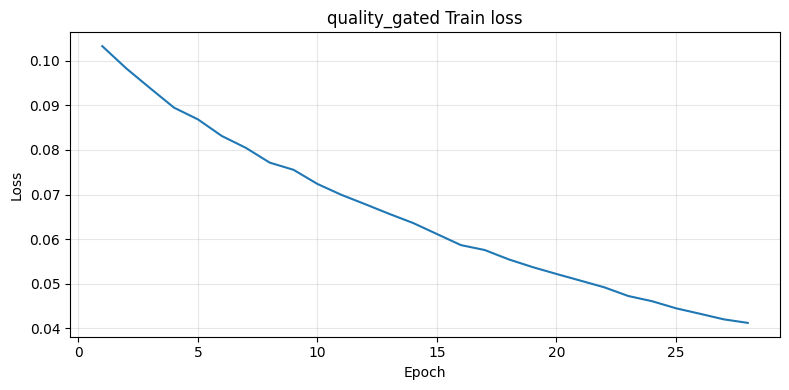

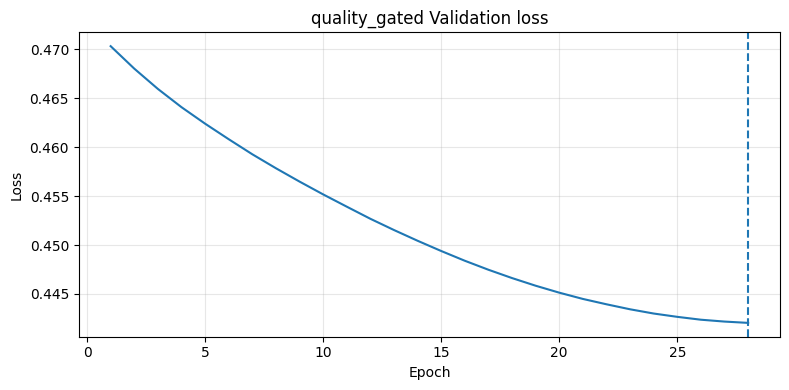

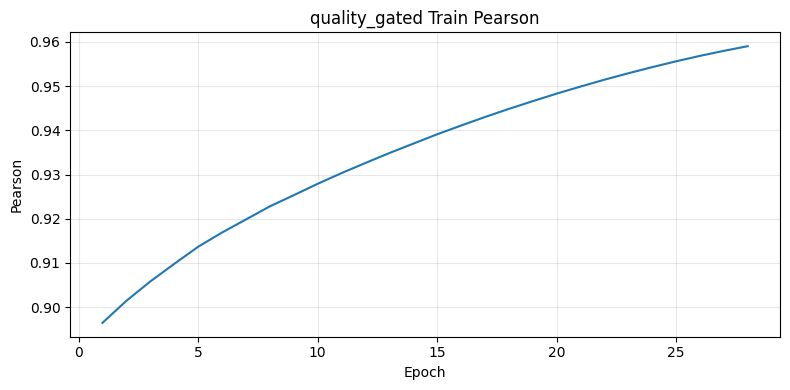

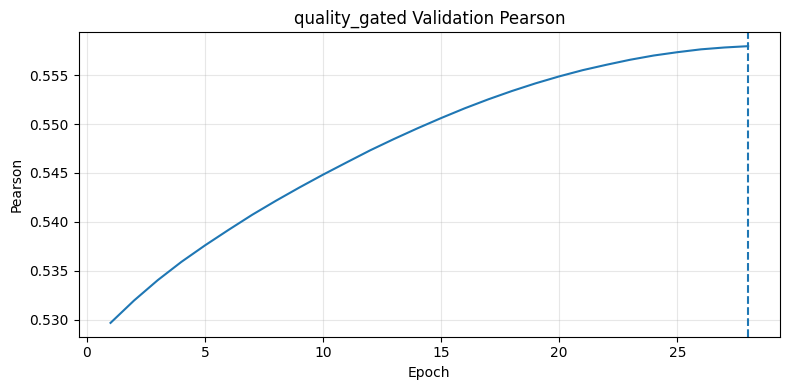

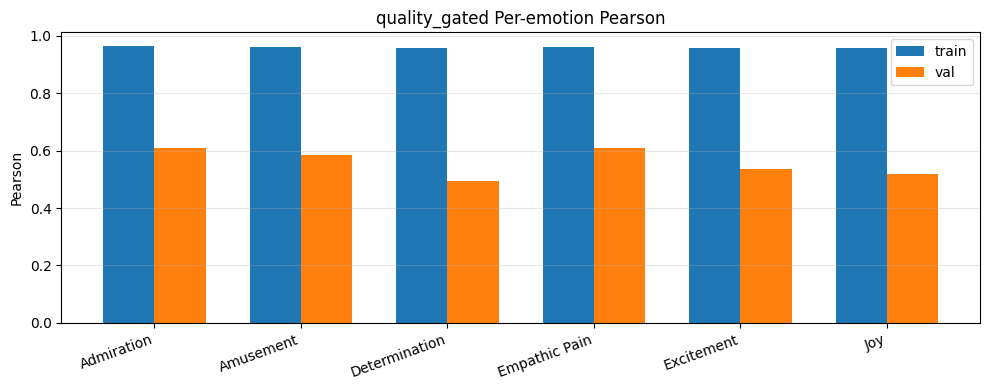

✅ Loaded best modality_transformer checkpoint from epoch=12 | best_corr=0.5452547305741806


/home/danila/networks/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(



=== modality_transformer Pearson per emotion (TRAIN) ===
Mean Pearson: 0.9695
  - Admiration    : 0.9711
  - Amusement     : 0.9730
  - Determination : 0.9686
  - Empathic Pain : 0.9640
  - Excitement    : 0.9710
  - Joy           : 0.9691

=== modality_transformer Pearson per emotion (VAL) ===
Mean Pearson: 0.5453
  - Admiration    : 0.6048
  - Amusement     : 0.5664
  - Determination : 0.4938
  - Empathic Pain : 0.6017
  - Excitement    : 0.5138
  - Joy           : 0.4911


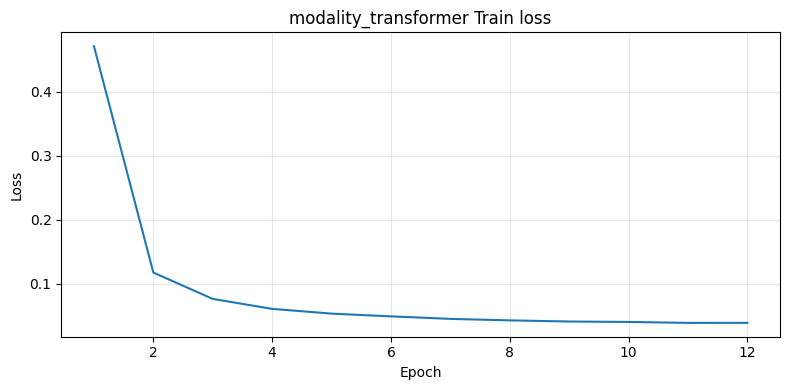

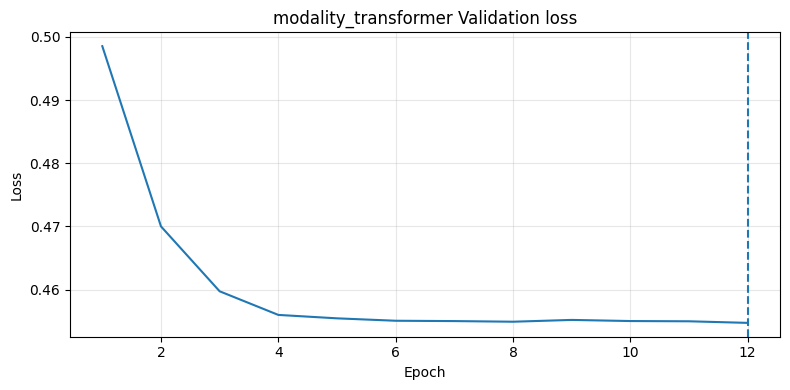

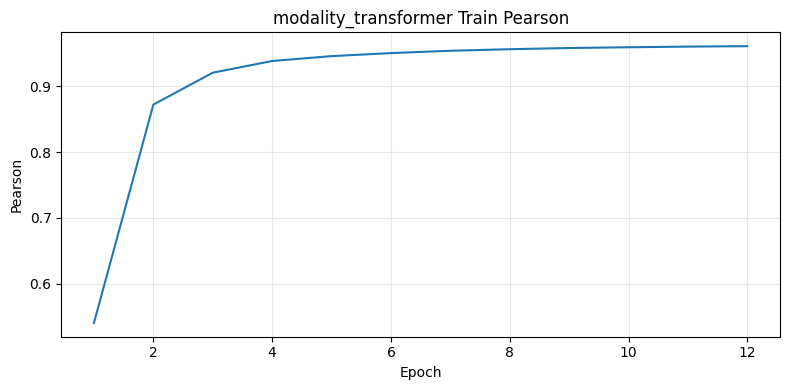

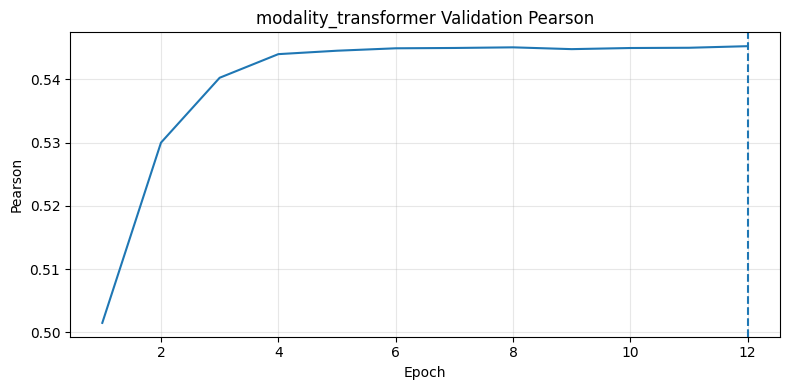

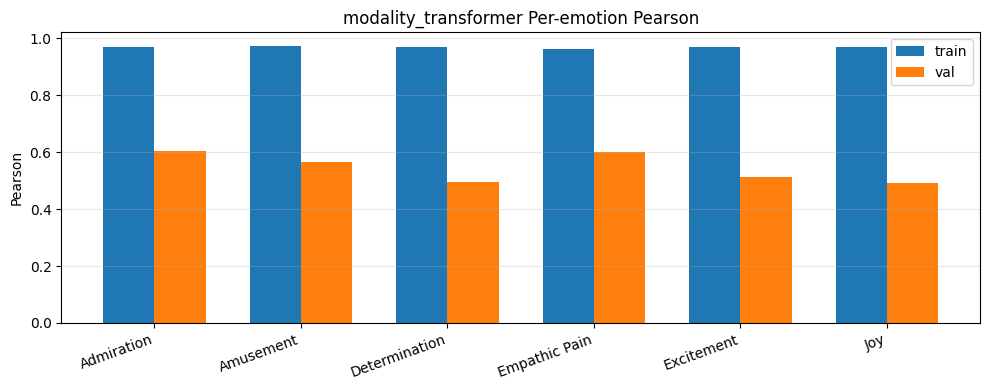

✅ Loaded best temporal_xattn checkpoint from epoch=15 | best_corr=0.5421040063414958

=== temporal_xattn Pearson per emotion (TRAIN) ===
Mean Pearson: 0.9700
  - Admiration    : 0.9715
  - Amusement     : 0.9740
  - Determination : 0.9694
  - Empathic Pain : 0.9645
  - Excitement    : 0.9714
  - Joy           : 0.9692

=== temporal_xattn Pearson per emotion (VAL) ===
Mean Pearson: 0.5421
  - Admiration    : 0.6031
  - Amusement     : 0.5614
  - Determination : 0.4900
  - Empathic Pain : 0.5958
  - Excitement    : 0.5111
  - Joy           : 0.4913


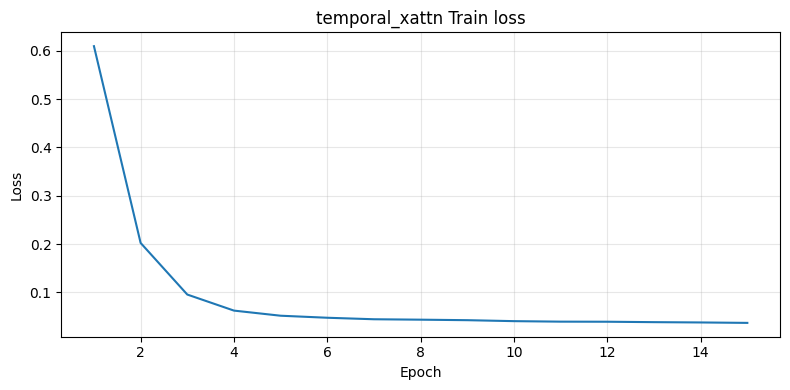

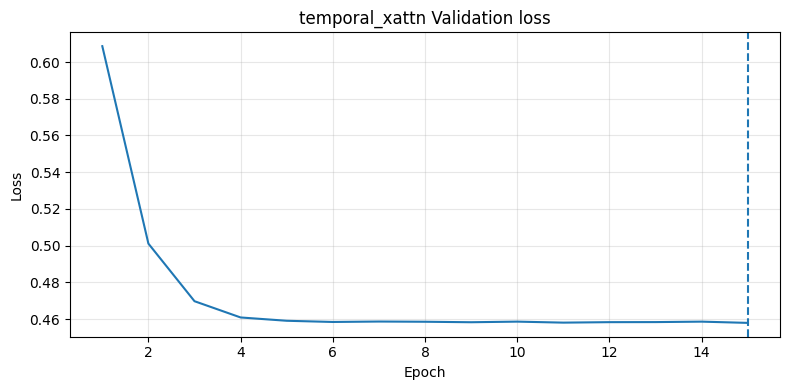

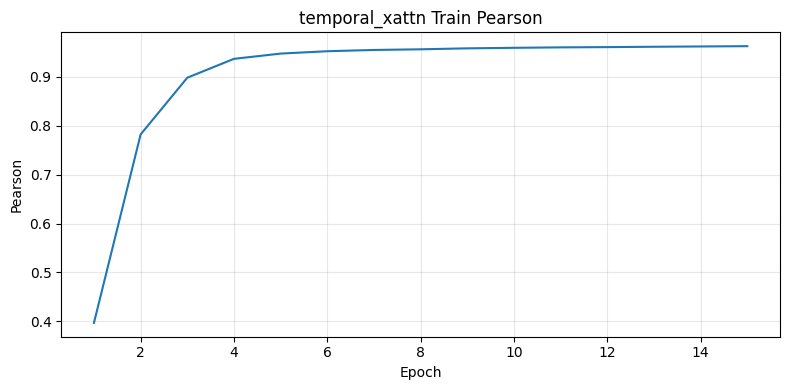

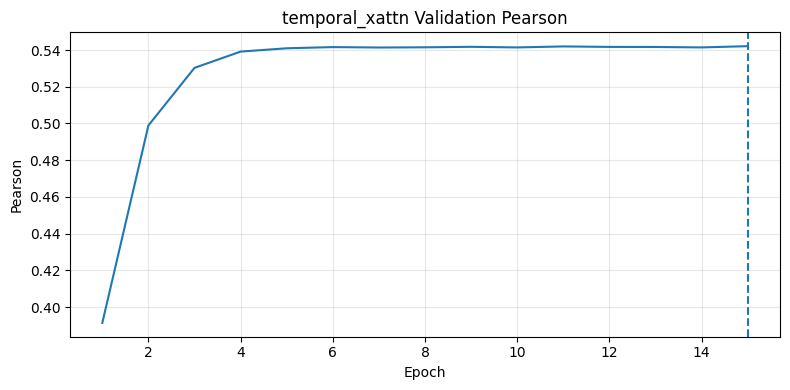

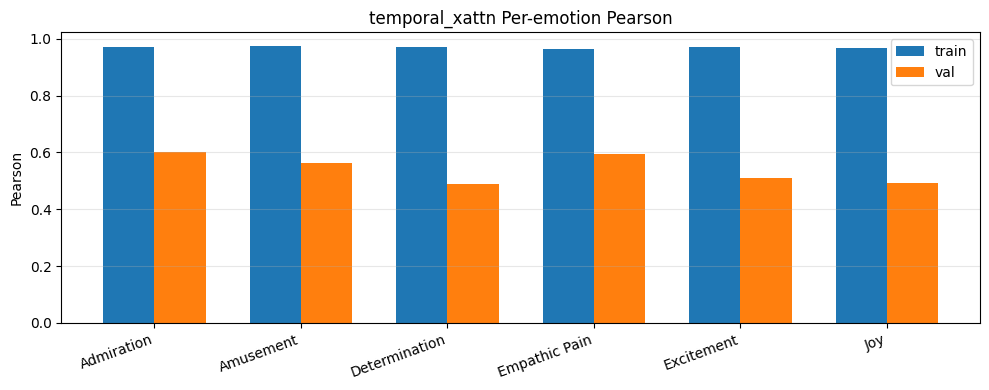

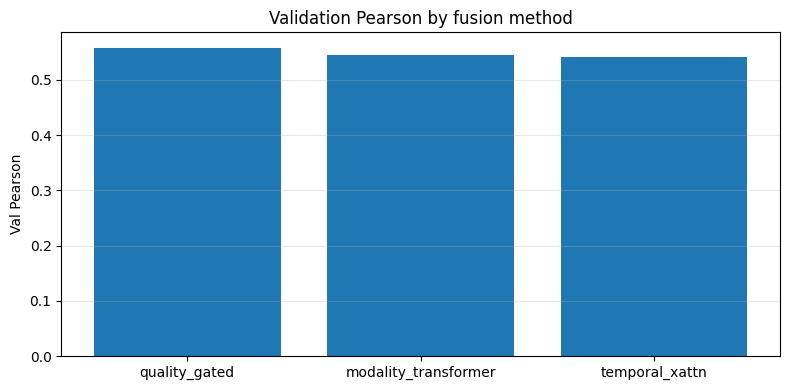

In [25]:
import matplotlib.pyplot as plt
import json
import numpy as np
import torch

# =========================
# Post-training evaluation: Pearson + plots (per method)
# =========================

@torch.inference_mode()
def collect_preds_static(model, loader):
    model.eval()
    all_p, all_y = [], []
    for xb, ab, qb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        ab = ab.to(DEVICE, non_blocking=True)
        qb = qb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        p, _ = model(xb, ab, qb)
        all_p.append(p.detach().float().cpu().numpy())
        all_y.append(yb.detach().float().cpu().numpy())
    P = np.concatenate(all_p, axis=0)
    Y = np.concatenate(all_y, axis=0)
    return P, Y

@torch.inference_mode()
def collect_preds_temporal(model, loader):
    model.eval()
    all_p, all_y = [], []
    for batch in loader:
        Pa, Ma, Qa, Pv, Mv, Qv, Pt, Mt, yb = batch
        Pa = Pa.to(DEVICE, non_blocking=True)
        Ma = Ma.to(DEVICE, non_blocking=True)
        Qa = Qa.to(DEVICE, non_blocking=True)
        Pv = Pv.to(DEVICE, non_blocking=True)
        Mv = Mv.to(DEVICE, non_blocking=True)
        Qv = Qv.to(DEVICE, non_blocking=True)
        Pt = Pt.to(DEVICE, non_blocking=True)
        Mt = Mt.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        p, _ = model(Pa, Ma, Qa, Pv, Mv, Qv, Pt, Mt)
        all_p.append(p.detach().float().cpu().numpy())
        all_y.append(yb.detach().float().cpu().numpy())
    P = np.concatenate(all_p, axis=0)
    Y = np.concatenate(all_y, axis=0)
    return P, Y

def denorm_targets(X_norm: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    return X_norm * std[None, :] + mean[None, :]

def pearson_per_dim_np_safe(P: np.ndarray, Y: np.ndarray, eps: float = 1e-8):
    corrs = []
    for k in range(P.shape[1]):
        x = P[:, k].astype(np.float64)
        y = Y[:, k].astype(np.float64)
        vx = x - x.mean()
        vy = y - y.mean()
        denom = np.sqrt((vx * vx).sum()) * np.sqrt((vy * vy).sum()) + eps
        corrs.append(float((vx * vy).sum() / denom))
    return float(np.mean(corrs)), corrs

summary = []

for method in FUSION_METHODS:
    run_dir = RUN_DIR_BASE / method
    ckpt_path = run_dir / "best_fusion.pt"
    hist_path = run_dir / "history.json"

    if not ckpt_path.exists():
        print(f"Skip {method}: missing {ckpt_path}")
        continue

    if method == "quality_gated":
        fusion = QualityAwareGatedFusion(hidden=32).to(DEVICE)
        loader_tr = train_loader_static
        loader_va = valid_loader_static
        collect_fn = collect_preds_static
    elif method == "modality_transformer":
        fusion = ModalityTokenTransformer(d_model=64, nhead=4, layers=2, dropout=0.1).to(DEVICE)
        loader_tr = train_loader_static
        loader_va = valid_loader_static
        collect_fn = collect_preds_static
    else:
        fusion = TemporalTokenTransformer(d_model=64, nhead=4, layers=2, dropout=0.1).to(DEVICE)
        loader_tr = train_loader_temporal
        loader_va = valid_loader_temporal
        collect_fn = collect_preds_temporal

    best_pkg = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    fusion.load_state_dict(best_pkg["model_state"], strict=True)
    fusion = fusion.to(DEVICE).eval()

    print(
        f"✅ Loaded best {method} checkpoint from epoch={best_pkg.get('epoch', 'NA')} "
        f"| best_corr={best_pkg.get('best_corr', 'NA')}"
    )

    P_tr_norm, Y_tr_norm = collect_fn(fusion, loader_tr)
    P_va_norm, Y_va_norm = collect_fn(fusion, loader_va)

    P_tr_raw = denorm_targets(P_tr_norm, y_mean, y_std)
    Y_tr_raw = denorm_targets(Y_tr_norm, y_mean, y_std)
    P_va_raw = denorm_targets(P_va_norm, y_mean, y_std)
    Y_va_raw = denorm_targets(Y_va_norm, y_mean, y_std)

    train_mean_corr, train_per_corr = pearson_per_dim_np_safe(P_tr_norm, Y_tr_norm)
    val_mean_corr, val_per_corr = pearson_per_dim_np_safe(P_va_norm, Y_va_norm)

    print(f"\n=== {method} Pearson per emotion (TRAIN) ===")
    print(f"Mean Pearson: {train_mean_corr:.4f}")
    for emo, c in zip(EMOTIONS, train_per_corr):
        print(f"  - {emo:14s}: {c:.4f}")

    print(f"\n=== {method} Pearson per emotion (VAL) ===")
    print(f"Mean Pearson: {val_mean_corr:.4f}")
    for emo, c in zip(EMOTIONS, val_per_corr):
        print(f"  - {emo:14s}: {c:.4f}")

    detailed_metrics = {
        "method": method,
        "best_epoch": int(best_pkg.get("epoch", -1)),
        "best_corr_from_ckpt": float(best_pkg.get("best_corr", float("nan"))),
        "train_mean_corr": float(train_mean_corr),
        "train_per_corr": {emo: float(c) for emo, c in zip(EMOTIONS, train_per_corr)},
        "val_mean_corr": float(val_mean_corr),
        "val_per_corr": {emo: float(c) for emo, c in zip(EMOTIONS, val_per_corr)},
    }
    with open(run_dir / "detailed_metrics_pearson.json", "w", encoding="utf-8") as f:
        json.dump(detailed_metrics, f, ensure_ascii=False, indent=2)

    summary.append({"method": method, "val_mean_corr": val_mean_corr})

    # plots per method
    if hist_path.exists():
        history = json.loads(hist_path.read_text())
        epochs = np.arange(1, len(history["train_loss"]) + 1)
        best_epoch_plot = int(best_pkg.get("epoch", -1))

        plt.figure(figsize=(8, 4))
        plt.plot(epochs, history["train_loss"])
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"{method} Train loss")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 4))
        plt.plot(epochs, history["val_loss"])
        if best_epoch_plot > 0:
            plt.axvline(best_epoch_plot, linestyle="--")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"{method} Validation loss")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 4))
        plt.plot(epochs, history["train_corr"])
        plt.xlabel("Epoch")
        plt.ylabel("Pearson")
        plt.title(f"{method} Train Pearson")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 4))
        plt.plot(epochs, history["val_corr"])
        if best_epoch_plot > 0:
            plt.axvline(best_epoch_plot, linestyle="--")
        plt.xlabel("Epoch")
        plt.ylabel("Pearson")
        plt.title(f"{method} Validation Pearson")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        x = np.arange(len(EMOTIONS))
        w = 0.35
        plt.figure(figsize=(10, 4))
        plt.bar(x - w/2, train_per_corr, width=w, label="train")
        plt.bar(x + w/2, val_per_corr, width=w, label="val")
        plt.xticks(x, EMOTIONS, rotation=20, ha="right")
        plt.ylabel("Pearson")
        plt.title(f"{method} Per-emotion Pearson")
        plt.legend()
        plt.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

# summary bar plot
if summary:
    labels = [s["method"] for s in summary]
    vals = [s["val_mean_corr"] for s in summary]
    plt.figure(figsize=(8, 4))
    plt.bar(labels, vals)
    plt.ylabel("Val Pearson")
    plt.title("Validation Pearson by fusion method")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()




=== quality_gated F1 (VAL) ===
Mean F1: 0.4295
  - Admiration    : 0.5290
  - Amusement     : 0.4102
  - Determination : 0.4062
  - Empathic Pain : 0.4894
  - Excitement    : 0.4027
  - Joy           : 0.3395


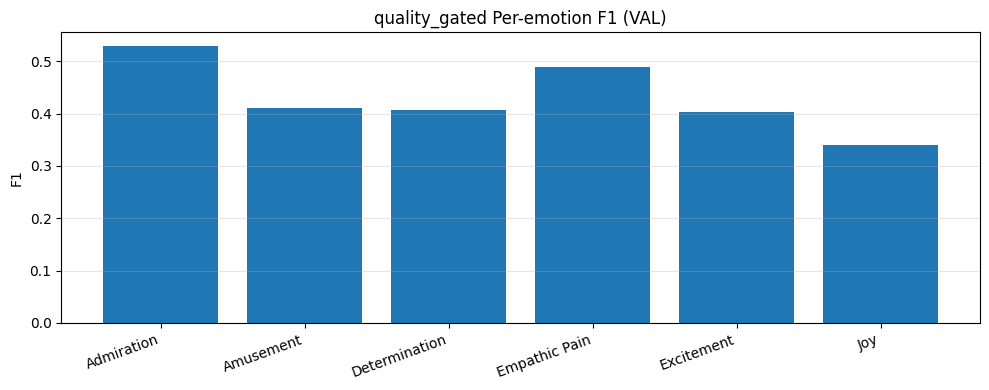


=== modality_transformer F1 (VAL) ===
Mean F1: 0.4319
  - Admiration    : 0.5391
  - Amusement     : 0.4131
  - Determination : 0.4196
  - Empathic Pain : 0.5053
  - Excitement    : 0.3842
  - Joy           : 0.3300


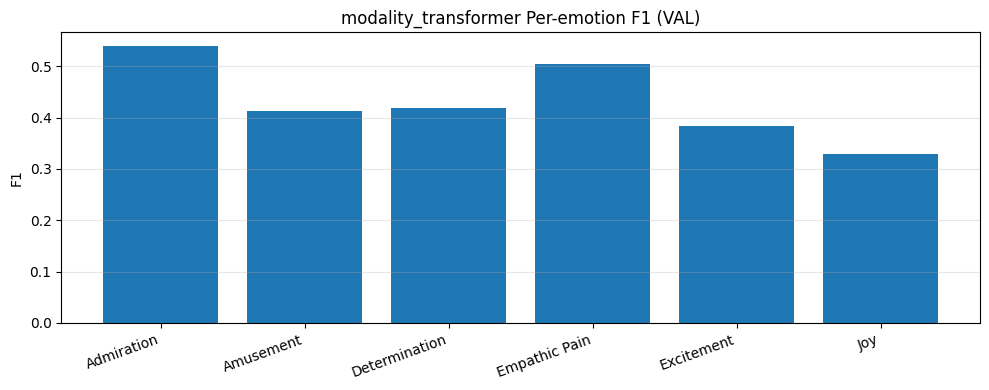


=== temporal_xattn F1 (VAL) ===
Mean F1: 0.4319
  - Admiration    : 0.5408
  - Amusement     : 0.4079
  - Determination : 0.4215
  - Empathic Pain : 0.5361
  - Excitement    : 0.3711
  - Joy           : 0.3142


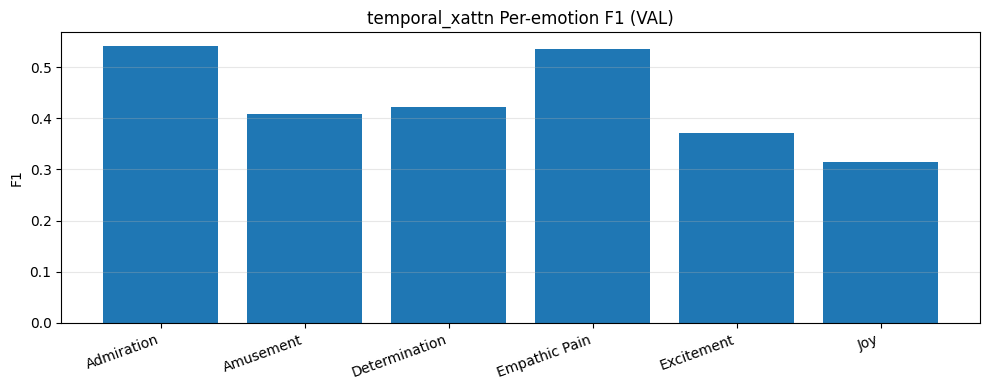

In [26]:
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt
import json

# =========================
# F1 with fixed target threshold and tuned prediction threshold (per method)
# =========================

ZERO_DIVISION = 0
TRUE_THRESHOLD = 0.5

def search_best_pred_threshold_per_emotion(
    P_raw: np.ndarray,
    Y_raw: np.ndarray,
    true_threshold: float = 0.5,
    grid_size: int = 301,
    zero_division: int = 0,
): 
    best_thresholds = []
    best_f1s = []
    curves = []

    for k in range(P_raw.shape[1]):
        y_true = (Y_raw[:, k] >= true_threshold).astype(np.int32)

        p_min = float(P_raw[:, k].min())
        p_max = float(P_raw[:, k].max())
        pred_grid = np.linspace(p_min, p_max, grid_size)

        best_thr = pred_grid[0]
        best_f1 = -1.0
        curve = []

        for pred_thr in pred_grid:
            y_pred = (P_raw[:, k] >= pred_thr).astype(np.int32)
            f1 = f1_score(y_true, y_pred, zero_division=zero_division)
            curve.append(float(f1))

            if f1 > best_f1:
                best_f1 = float(f1)
                best_thr = float(pred_thr)

        best_thresholds.append(float(best_thr))
        best_f1s.append(float(best_f1))
        curves.append((pred_grid, np.array(curve, dtype=np.float32)))

    return best_thresholds, best_f1s, curves

def f1_per_dim_with_pred_thresholds(
    P_raw: np.ndarray,
    Y_raw: np.ndarray,
    pred_thresholds: list[float],
    true_threshold: float = 0.5,
    zero_division: int = 0,
): 
    f1s = []
    for k, pred_thr in enumerate(pred_thresholds):
        y_true = (Y_raw[:, k] >= true_threshold).astype(np.int32)
        y_pred = (P_raw[:, k] >= pred_thr).astype(np.int32)
        f1s.append(float(f1_score(y_true, y_pred, zero_division=zero_division)))
    return float(np.mean(f1s)), f1s

# compute per-method F1 using thresholds from TRAIN
for method in FUSION_METHODS:
    run_dir = RUN_DIR_BASE / method
    metrics_path = run_dir / "detailed_metrics_pearson.json"
    if not metrics_path.exists():
        continue

    ckpt_path = run_dir / "best_fusion.pt"
    if method == "quality_gated":
        fusion = QualityAwareGatedFusion(hidden=32).to(DEVICE)
        loader_tr = train_loader_static
        loader_va = valid_loader_static
        collect_fn = collect_preds_static
    elif method == "modality_transformer":
        fusion = ModalityTokenTransformer(d_model=64, nhead=4, layers=2, dropout=0.1).to(DEVICE)
        loader_tr = train_loader_static
        loader_va = valid_loader_static
        collect_fn = collect_preds_static
    else:
        fusion = TemporalTokenTransformer(d_model=64, nhead=4, layers=2, dropout=0.1).to(DEVICE)
        loader_tr = train_loader_temporal
        loader_va = valid_loader_temporal
        collect_fn = collect_preds_temporal

    best_pkg = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    fusion.load_state_dict(best_pkg["model_state"], strict=True)
    fusion = fusion.to(DEVICE).eval()

    P_tr_norm, Y_tr_norm = collect_fn(fusion, loader_tr)
    P_va_norm, Y_va_norm = collect_fn(fusion, loader_va)

    P_tr_raw = denorm_targets(P_tr_norm, y_mean, y_std)
    Y_tr_raw = denorm_targets(Y_tr_norm, y_mean, y_std)
    P_va_raw = denorm_targets(P_va_norm, y_mean, y_std)
    Y_va_raw = denorm_targets(Y_va_norm, y_mean, y_std)

    best_pred_thresholds, train_best_f1, f1_curves = search_best_pred_threshold_per_emotion(
        P_tr_raw, Y_tr_raw, true_threshold=TRUE_THRESHOLD, grid_size=301, zero_division=ZERO_DIVISION
    )
    val_mean_f1, val_per_f1 = f1_per_dim_with_pred_thresholds(
        P_va_raw, Y_va_raw, best_pred_thresholds, true_threshold=TRUE_THRESHOLD, zero_division=ZERO_DIVISION
    )

    print(f"\n=== {method} F1 (VAL) ===")
    print(f"Mean F1: {val_mean_f1:.4f}")
    for emo, c in zip(EMOTIONS, val_per_f1):
        print(f"  - {emo:14s}: {c:.4f}")

    # Save metrics with F1
    with open(metrics_path, "r", encoding="utf-8") as f:
        detailed_metrics = json.load(f)
    detailed_metrics["val_mean_f1"] = float(val_mean_f1)
    detailed_metrics["val_per_f1"] = {emo: float(c) for emo, c in zip(EMOTIONS, val_per_f1)}
    detailed_metrics["best_pred_thresholds"] = {emo: float(t) for emo, t in zip(EMOTIONS, best_pred_thresholds)}

    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(detailed_metrics, f, ensure_ascii=False, indent=2)

    # Plot per-emotion F1 curves (TRAIN)
    x = np.arange(len(EMOTIONS))
    plt.figure(figsize=(10, 4))
    plt.bar(x, val_per_f1)
    plt.xticks(x, EMOTIONS, rotation=20, ha="right")
    plt.ylabel("F1")
    plt.title(f"{method} Per-emotion F1 (VAL)")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()